# Olist Brazilian E-Commerce Data Analysis

## Project Introduction

This project analyzes the Olist Brazilian E-Commerce dataset to understand sales performance, customer behavior, product performance, payment methods, delivery performance, reviews, and geographic distribution.

The analysis follows a complete data analytics workflow, including data cleaning, preprocessing, transformation, feature engineering, exploratory data analysis (EDA), statistical analysis, data visualization, and business analysis.

The main objective is to identify meaningful patterns and business insights from the data and use them to develop practical, data-driven business recommendations.

### Key Areas of Analysis

- Order and sales performance
- Customer behavior and customer value
- Product and category performance
- Seller performance
- Payment methods
- Delivery performance
- Customer reviews and satisfaction
- Order-value distribution and outliers
- Geographic customer and revenue distribution
- Statistical relationships between important business variables

### Tools & Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- SciPy
- Jupyter Notebook

### Business Objective

The final goal of this project is to transform raw e-commerce data into actionable business insights and recommendations that can support better decisions related to customer retention, delivery performance, product strategy, and revenue growth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

#  1. Data Loading and Understanding
### What does the data contain?

## orders data:

In [2]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
category_translation = pd.read_csv("../data/product_category_name_translation.csv")

In [3]:
datasets = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "orders": orders,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
geolocation: (1000163, 5)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
sellers: (3095, 4)
category_translation: (71, 2)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()
#there are 3% missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [7]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
# percentage of each order status
orders["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [9]:
orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
orders[
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].tail()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00


In [11]:
# converting the object to datetime:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
# max parchase date: min purchase date :
print("Earliest order:",orders["order_purchase_timestamp"].min())
print("Latest order:",orders["order_purchase_timestamp"].max())


Earliest order: 2016-09-04 21:15:19
Latest order: 2018-10-17 17:30:18


## customer data:

In [12]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [13]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [14]:
customers.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [15]:
customers["customer_zip_code_prefix"].mean()

np.float64(35137.47458291851)

In [16]:
customers["customer_id"].nunique()

99441

In [17]:
orders["customer_id"].nunique()

99441

In [18]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [19]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [21]:
print("Total product value:", order_items["price"].sum())
print("Total freight value:", order_items["freight_value"].sum())

Total product value: 13591643.7
Total freight value: 2251909.54


In [22]:
print("Unique products:", order_items["product_id"].nunique())
print("Unique sellers", order_items["seller_id"].nunique())
print("Unique orders:", order_items["order_id"].nunique())

Unique products: 32951
Unique sellers 3095
Unique orders: 98666


In [23]:
# Count orders that exist in the orders table but have no matching order-item records

orders_without_items = orders[
    ~orders["order_id"].isin(order_items["order_id"])
]
# Check the complete status distribution for orders without corresponding order items

orders_without_items["order_status"].value_counts()


order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [24]:
# Identify delivered orders that do not have corresponding order-item records
delivered_without_items = orders_without_items[
    orders_without_items["order_status"] == "delivered"
]

# Display the number of delivered orders without item records
print("Delivered orders without items:", len(delivered_without_items))

Delivered orders without items: 0


In [25]:
# Display the IDs and relevant dates of delivered orders without item records
delivered_without_items[
    [
        "order_id",
        "customer_id",
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
]

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date


 ## products table

In [26]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [27]:
# Examine product columns, data types, missing values, and memory usage
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [28]:
products.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [29]:
# Count missing values in each product attribute to assess data completeness
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [30]:
# Calculate the percentage of missing values in each product attribute
products.isnull().mean().mul(100).round(2)

product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

In [31]:
missing_category = products[products["product_category_name"].isna()]

In [32]:
missing_category.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [33]:
# Count the number of products in each product category
products["product_category_name"].value_counts()

product_category_name
cama_mesa_banho                                   3029
esporte_lazer                                     2867
moveis_decoracao                                  2657
beleza_saude                                      2444
utilidades_domesticas                             2335
automotivo                                        1900
informatica_acessorios                            1639
brinquedos                                        1411
relogios_presentes                                1329
telefonia                                         1134
bebes                                              919
perfumaria                                         868
papelaria                                          849
fashion_bolsas_e_acessorios                        849
cool_stuff                                         789
ferramentas_jardim                                 753
pet_shop                                           719
eletronicos                                

In [34]:
products["product_category_name"].value_counts().sum()

np.int64(32341)

## category translation

In [35]:
# Display the category translation table to understand the Portuguese-to-English mapping
category_translation.head() 

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [36]:
# Check the structure and data types of the category translation table
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


## Sellers Table

In [37]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [38]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [39]:
sellers.describe(include= "all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


## Payments Table

In [40]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [41]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [42]:
payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


## Reviews Table

In [43]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [44]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [45]:
# Count the number of reviews for each rating score

reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [46]:
# Calculate the percentage distribution of each customer review score

review_persentage = (
    reviews['review_score'].value_counts(normalize=True).sort_index()
    .mul(100)
    .round(2)
)
review_persentage

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

## Geolocation Table

In [47]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [48]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


# 1. Data Preprocessing
### How do we prepare the data for analysis?

In [49]:
# Count completely duplicated rows in each dataset

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

customers: 0 duplicate rows
geolocation: 261831 duplicate rows
order_items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
category_translation: 0 duplicate rows


In [50]:
print("Unique ZIP prefixes:",
      geolocation["geolocation_zip_code_prefix"].nunique()
     )

Unique ZIP prefixes: 19015


In [51]:
print("Unique location records:",
      geolocation.drop_duplicates().shape[0]
     )

Unique location records: 738332


In [52]:
# Count missing values in each column of every dataset

for name, df in datasets.items():
     print(f"\n{name}")
     print(df.isnull().sum())


customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

orders
order_id            

# Data Cleaning

In [53]:
# Compare missing delivery information across different order statuses
orders[orders["order_delivered_customer_date"].isna()]["order_status"].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [54]:
# Compare missing carrier dates across different order statuses
orders[orders["order_delivered_carrier_date"].isna()]["order_status"].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [55]:
# Check which order statuses have missing approval dates
orders[orders["order_approved_at"].isna()]["order_status"].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [56]:
# Find order-item records belonging to products with missing category information
missing_products_in_orders = order_items[
    order_items["product_id"].isin(missing_category["product_id"])
]

# Count the affected order-item records and unique products
print("Order-item records:", len(missing_products_in_orders))
print("Unique products:", missing_products_in_orders["product_id"].nunique())

Order-item records: 1603
Unique products: 610


In [57]:
# Identify products with missing physical measurements
missing_dimensions = products[
    products["product_weight_g"].isna()
]

# Display the affected product records
missing_dimensions

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
# Calculate the percentage of reviews with missing title or message text
review_text_missing = (
    reviews[["review_comment_title", "review_comment_message"]]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

review_text_missing

review_comment_title      88.34
review_comment_message    58.70
dtype: float64

# Data Transformation
### Converting date columns from object to datetime format for time-based analysis.

In [59]:
# Date columns in Orders table
date_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns_orders:
    orders[col] = pd.to_datetime(orders[col])

orders[date_columns_orders].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [60]:
# Convert review date columns from object to datetime format
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]
for col in review_date_columns:
    reviews[col] = pd.to_datetime(reviews[col])

reviews[review_date_columns].dtypes

review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

In [61]:
# Convert the seller shipping deadline from text to datetime format
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

# Verify the conversion
order_items["shipping_limit_date"].dtype

dtype('<M8[ns]')

In [62]:
# Check for orders approved before they were purchased
invalid_approval = orders[
    orders["order_approved_at"] < orders["order_purchase_timestamp"]
]

print("Orders with approval before purchase:", len(invalid_approval))

Orders with approval before purchase: 0


In [63]:
# Check for orders delivered to customers before they were purchased
invalid_delivery = orders[
    orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]
]

print("Orders delivered before purchase:", len(invalid_delivery))

Orders delivered before purchase: 0


In [64]:
# Check for orders delivered to customers before being handed to the carrier
invalid_carrier_delivery = orders[
    orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]
]

print("Orders delivered before carrier date:", len(invalid_carrier_delivery))

Orders delivered before carrier date: 23


In [65]:
# Check for negative or zero values in important transaction fields
print("Negative prices:", (order_items["price"] < 0).sum())
print("Zero prices:", (order_items["price"] == 0).sum())

print("Negative freight:", (order_items["freight_value"] < 0).sum())
print("Zero freight:", (order_items["freight_value"] == 0).sum())

Negative prices: 0
Zero prices: 0
Negative freight: 0
Zero freight: 383


In [66]:
# Check for invalid negative or zero values in product physical measurements
measurement_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in measurement_columns:
    print(f"\n{col}")
    print("Negative values:", (products[col] < 0).sum())
    print("Zero values:", (products[col] == 0).sum())


product_weight_g
Negative values: 0
Zero values: 4

product_length_cm
Negative values: 0
Zero values: 0

product_height_cm
Negative values: 0
Zero values: 0

product_width_cm
Negative values: 0
Zero values: 0


In [67]:
# Display products with zero recorded weight for further data-quality investigation
zero_weight_products = products[products["product_weight_g"] == 0]

zero_weight_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [68]:
products_clean = products.copy()

In [69]:
# Replace impossible zero product weights with missing values
products_clean.loc[
    products_clean["product_weight_g"] == 0,
    "product_weight_g"
] = np.nan

In [70]:
# Verify that no zero product weights remain in the cleaned dataset
print(
    "Zero weights after cleaning:",
    (products_clean["product_weight_g"] == 0).sum()
)

Zero weights after cleaning: 0


In [71]:
# Replace missing product categories with "Unknown" to preserve sold products
products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("Unknown")
)

In [72]:
# Check whether any product categories are still missing
print(
    "Missing categories after cleaning:",
    products_clean["product_category_name"].isna().sum()
)

Missing categories after cleaning: 0


In [73]:
products_clean

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [74]:
# Check the remaining missing values in the cleaned products dataset
products_clean.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                6
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [75]:
# Check the category translation table for duplicate rows and missing values
print("Duplicate rows:", category_translation.duplicated().sum())
print("\nMissing values:")
print(category_translation.isnull().sum())

Duplicate rows: 0

Missing values:
product_category_name            0
product_category_name_english    0
dtype: int64


In [76]:
# Check whether each Portuguese category has only one English translation
print(
    "Unique Portuguese categories:",
    category_translation["product_category_name"].nunique()
)

print(
    "Unique English categories:",
    category_translation["product_category_name_english"].nunique()
)

Unique Portuguese categories: 71
Unique English categories: 71


In [77]:
# Add the English product category to the cleaned products dataset
products_clean = products_clean.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [78]:
# Check the updated product dataset structure after adding English categories
products_clean[[
    "product_category_name",
    "product_category_name_english"
]].head()

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares


In [79]:
# Check whether any products are missing an English category after the merge
print(
    "Missing English categories:",
    products_clean["product_category_name_english"].isna().sum()
)

Missing English categories: 623


In [80]:
# Label products without a known category as "Unknown"
products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"].fillna("Unknown")
)

In [81]:
# Verify that every product now has an English category label
print(
    "Missing English categories after cleaning:",
    products_clean["product_category_name_english"].isna().sum()
)

Missing English categories after cleaning: 0


In [82]:
# Check the unique payment methods available in the dataset
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [83]:
# Count how many payment records exist for each payment method
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [84]:
# Check for invalid installment values
print("Installments less than 1:",
      (payments["payment_installments"] < 1).sum())

# Check for negative payment values
print("Negative payment values:",
      (payments["payment_value"] < 0).sum())

Installments less than 1: 2
Negative payment values: 0


In [85]:
# Check the range of payment installments
print("Minimum installments:",
      payments["payment_installments"].min())

print("Maximum installments:",
      payments["payment_installments"].max())

# Check the range of payment values
print("Minimum payment:",
      payments["payment_value"].min())

print("Maximum payment:",
      payments["payment_value"].max())

Minimum installments: 0
Maximum installments: 24
Minimum payment: 0.0
Maximum payment: 13664.08


In [86]:
# Display payment records with zero installments
zero_installment_payments = payments[
    payments["payment_installments"] == 0
]

zero_installment_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [87]:
# Count payment records with a payment value of zero
print(
    "Zero payment values:",
    (payments["payment_value"] == 0).sum()
)

Zero payment values: 9


In [88]:
# Check which payment methods have zero-value payment records
zero_payment = payments[payments["payment_value"] == 0]

zero_payment["payment_type"].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

In [89]:
# Display the zero-value payment records for investigation
zero_payment

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [90]:
payments_clean = payments.copy()

In [91]:
# Replace invalid zero installment values with missing values
payments_clean.loc[
    payments_clean["payment_installments"] == 0,
    "payment_installments"
] = np.nan

In [92]:
# Verify that no zero-installment records remain
print(
    "Zero installments after cleaning:",
    (payments_clean["payment_installments"] == 0).sum()
)

Zero installments after cleaning: 0


## Validate review scores

In [93]:
# Check for review scores outside the valid range of 1 to 5
invalid_reviews = reviews[
    (reviews["review_score"] < 1) |
    (reviews["review_score"] > 5)
]

print("Invalid review scores:", len(invalid_reviews))

Invalid review scores: 0


In [94]:
# Check for invalid installment values after cleaning
invalid_installments = payments_clean[
    payments_clean["payment_installments"] < 1
]

print("Invalid installments:", len(invalid_installments))

Invalid installments: 0


In [95]:
# Check whether primary IDs are unique in their respective tables
print("Customers:", customers["customer_id"].nunique(), "of", len(customers))
print("Orders:", orders["order_id"].nunique(), "of", len(orders))
print("Products:", products_clean["product_id"].nunique(), "of", len(products_clean))
print("Sellers:", sellers["seller_id"].nunique(), "of", len(sellers))
print("Reviews:", reviews["review_id"].nunique(), "of", len(reviews))

Customers: 99441 of 99441
Orders: 99441 of 99441
Products: 32951 of 32951
Sellers: 3095 of 3095
Reviews: 98410 of 99224


In [96]:
# Find review IDs that appear more than once
duplicate_review_ids = reviews[
    reviews["review_id"].duplicated(keep=False)
    ]
print("Rows with repeated review IDs:", len(duplicate_review_ids))
print("Repeated review IDs:", duplicate_review_ids["review_id"].nunique())

Rows with repeated review IDs: 1603
Repeated review IDs: 789


In [97]:
# Display examples of repeated review IDs and their review information
duplicate_review_ids.sort_values(
    ["review_id", "order_id"]
)[[
    "review_id",
    "order_id",
    "review_score",
    "review_comment_title",
    "review_comment_message"
]].head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid..."
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid..."
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...


In [98]:
# Check whether an order has multiple review records
review_order_counts = reviews["order_id"].value_counts()

print(
    "Orders with multiple reviews:",
    (review_order_counts > 1).sum()
)

Orders with multiple reviews: 547


In [99]:
# Show the maximum number of reviews associated with a single order
print(
    "Maximum reviews for one order:",
    review_order_counts.max()
)

Maximum reviews for one order: 3


# Feature Engineering

## Delivery time

In [100]:
# Calculate the number of days between order purchase and customer delivery
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

orders["delivery_days"].head()

0     8.436574
1    13.782037
2     9.394213
3    13.208750
4     2.873877
Name: delivery_days, dtype: float64

In [101]:
# Check how many orders have a calculated delivery time
print("Orders with delivery time:", orders["delivery_days"].notna().sum())

# Check how many orders still have no delivery time
print("Orders without delivery time:", orders["delivery_days"].isna().sum())

Orders with delivery time: 96476
Orders without delivery time: 2965


In [102]:
# Get basic statistics for completed order delivery times
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

In [103]:
 # Calculate delivery delay compared with the estimated delivery date
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

orders["delivery_delay_days"].head()

0    -7.107488
1    -5.355729
2   -17.245498
3   -12.980069
4    -9.238171
Name: delivery_delay_days, dtype: float64

In [104]:
# Summarize how early or late orders were delivered
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [105]:
# Count orders delivered early, on time, and late
print("Delivered early:",
      (orders["delivery_delay_days"] < 0).sum())

print("Delivered on time:",
      (orders["delivery_delay_days"] == 0).sum())

print("Delivered late:",
      (orders["delivery_delay_days"] > 0).sum())

Delivered early: 88649
Delivered on time: 0
Delivered late: 7827


In [106]:
# Compare delivery and estimated dates at the calendar-day level
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"].dt.normalize()
    - orders["order_estimated_delivery_date"].dt.normalize()
).dt.days

orders["delivery_delay_days"].head()

0    -8.0
1    -6.0
2   -18.0
3   -13.0
4   -10.0
Name: delivery_delay_days, dtype: float64

In [107]:
# Classify delivered orders based on calendar-day difference
print("Delivered early:",
      (orders["delivery_delay_days"] < 0).sum())

print("Delivered on time:",
      (orders["delivery_delay_days"] == 0).sum())

print("Delivered late:",
      (orders["delivery_delay_days"] > 0).sum())

Delivered early: 88649
Delivered on time: 1292
Delivered late: 6535


In [108]:
# Calculate the percentage of delivered orders in each delivery category
total_delivered = orders["delivery_delay_days"].notna().sum()

print("Early %:",
      round((orders["delivery_delay_days"] < 0).sum() / total_delivered * 100, 2))

print("On-time %:",
      round((orders["delivery_delay_days"] == 0).sum() / total_delivered * 100, 2))

print("Late %:",
      round((orders["delivery_delay_days"] > 0).sum() / total_delivered * 100, 2))

Early %: 91.89
On-time %: 1.34
Late %: 6.77


## Order value

In [109]:
# Calculate the total payment value for each order
order_payment_total = (
    payments_clean
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

order_payment_total = order_payment_total.rename(
    columns={"payment_value": "order_total_value"}
)

order_payment_total.head()

,order_id,order_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [110]:
# Add the total payment value to each order
orders = orders.merge(
    order_payment_total,
    on="order_id",
    how="left"
)

orders[[
    "order_id",
    "order_status",
    "order_total_value"
]].head()

,order_id,order_status,order_total_value
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,28.62


In [111]:
# Validate that the payment merge did not create duplicate order rows
print("Orders after merge:", len(orders))
print("Unique order IDs:", orders["order_id"].nunique())

Orders after merge: 99441
Unique order IDs: 99441


In [112]:
# Check how many orders do not have a recorded payment total
print(
    "Orders without payment total:",
    orders["order_total_value"].isna().sum()
)

Orders without payment total: 1


In [113]:
# Find the order that has no recorded payment information
missing_payment_order = orders[
    orders["order_total_value"].isna()
]

missing_payment_order[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_total_value"
    ]
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_total_value
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,NaN


In [114]:
# Store the order ID with missing payment information
missing_order_id = missing_payment_order["order_id"].iloc[0]

print("Missing payment order:", missing_order_id)

# Check whether the order exists in order_items
print(
    "Order items:",
    (order_items["order_id"] == missing_order_id).sum()
)

# Check whether the order exists in reviews
print(
    "Reviews:",
    (reviews["order_id"] == missing_order_id).sum()
)

# Check whether the order exists in payments
print(
    "Payments:",
    (payments_clean["order_id"] == missing_order_id).sum()
)

Missing payment order: bfbd0f9bdef84302105ad712db648a6c
Order items: 3
Reviews: 1
Payments: 0


In [115]:
# Display the items belonging to this order
missing_order_items = order_items[
    order_items["order_id"] == missing_order_id
]

missing_order_items[
    ["order_id", "product_id", "seller_id", "price", "freight_value"]
]

,order_id,product_id,seller_id,price,freight_value
84389,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83
84390,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83
84391,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,44.99,2.83


In [116]:
# Calculate the total value associated with each order item
order_items["item_total_value"] = (
    order_items["price"] +
    order_items["freight_value"]
)

# Display the result
order_items[
    ["order_id", "price", "freight_value", "item_total_value"]
].head()

,order_id,price,freight_value,item_total_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [117]:
# Calculate total product + freight value for each order
order_item_total = (
    order_items
    .groupby("order_id")["item_total_value"]
    .sum()
    .reset_index()
)

# Give the aggregated column a clear name
order_item_total = order_item_total.rename(
    columns={"item_total_value": "order_item_value"}
)

# View the result
order_item_total.head()

,order_id,order_item_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [118]:
# Add the calculated item value to the order-level dataset
orders = orders.merge(
    order_item_total,
    on="order_id",
    how="left"
)

# Check the result
orders[
    ["order_id", "order_total_value", "order_item_value"]
].head()

,order_id,order_total_value,order_item_value
0,e481f51cbdc54678b7cc49136f2d6af7,38.71,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,141.46,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,179.12,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,72.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,28.62,28.62


In [119]:
# Validate that the merge did not duplicate orders
print("Total orders:", len(orders))
print("Unique orders:", orders["order_id"].nunique())

Total orders: 99441
Unique orders: 99441


In [120]:
# Extract useful time-based features from the order purchase timestamp
orders["order_year"] = orders["order_purchase_timestamp"].dt.year

orders["order_month"] = orders["order_purchase_timestamp"].dt.month

orders["order_day"] = orders["order_purchase_timestamp"].dt.day

orders["order_day_of_week"] = (
    orders["order_purchase_timestamp"].dt.day_name()
)

# Display the new features
orders[
    [
        "order_purchase_timestamp",
        "order_year",
        "order_month",
        "order_day",
        "order_day_of_week"
    ]
].head()

,order_purchase_timestamp,order_year,order_month,order_day,order_day_of_week
0,2017-10-02 10:56:33,2017,10,2,Monday
1,2018-07-24 20:41:37,2018,7,24,Tuesday
2,2018-08-08 08:38:49,2018,8,8,Wednesday
3,2017-11-18 19:28:06,2017,11,18,Saturday
4,2018-02-13 21:18:39,2018,2,13,Tuesday


In [121]:
# Create a monthly period for time-series analysis
orders["order_month_period"] = (
    orders["order_purchase_timestamp"].dt.to_period("M")
)

orders["order_month_period"].head()

0    2017-10
1    2018-07
2    2018-08
3    2017-11
4    2018-02
Name: order_month_period, dtype: period[M]

In [122]:
# Add the actual unique customer ID to the orders dataset
orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

# Check the result
orders[[
    "customer_id",
    "customer_unique_id",
    "order_id"
]].head()

,customer_id,customer_unique_id,order_id
0,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7
1,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451
2,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d
3,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a
4,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159


In [123]:
# Count the number of orders placed by each real customer
customer_analysis = (
    orders.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

customer_analysis.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [124]:
# Check the number of real customers and their order frequency
print("Total real customers:", len(customer_analysis))

print(
    "One-time customers:",
    (customer_analysis["total_orders"] == 1).sum()
)

print(
    "Repeat customers:",
    (customer_analysis["total_orders"] > 1).sum()
)

Total real customers: 96096
One-time customers: 93099
Repeat customers: 2997


In [125]:
# Classify customers based on their order frequency
customer_analysis["customer_type"] = np.where(
    customer_analysis["total_orders"] > 1,
    "Repeat Customer",
    "One-time Customer"
)

In [126]:
customer_analysis["customer_type"].value_counts()

customer_type
One-time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64

In [127]:
# Calculate the percentage of repeat customers
repeat_percentage = (
    (customer_analysis["total_orders"] > 1).sum()
    / len(customer_analysis)
    * 100
)

print("Repeat customer percentage:", round(repeat_percentage, 2), "%")

Repeat customer percentage: 3.12 %


In [128]:
# Calculate total spending for each real customer
customer_spending = (
    orders
    .groupby("customer_unique_id")["order_total_value"]
    .sum()
    .reset_index(name="total_spent")
)

customer_spending.head()

,customer_unique_id,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [129]:
# Add total spending to the customer analysis table
customer_analysis = customer_analysis.merge(
    customer_spending,
    on="customer_unique_id",
    how="left"
)


customer_analysis

,customer_unique_id,total_orders,customer_type,total_spent
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-time Customer,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time Customer,27.19
2,0000f46a3911fa3c0805444483337064,1,One-time Customer,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-time Customer,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,One-time Customer,196.89
...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,1,One-time Customer,2067.42
96092,fffea47cd6d3cc0a88bd621562a9d061,1,One-time Customer,84.58
96093,ffff371b4d645b6ecea244b27531430a,1,One-time Customer,112.46
96094,ffff5962728ec6157033ef9805bacc48,1,One-time Customer,133.69


In [130]:
# Calculate the average order value for each real customer
customer_avg_order = (
    orders
    .groupby("customer_unique_id")["order_total_value"]
    .mean()
    .reset_index(name="average_order_value")
)

customer_avg_order.head()

,customer_unique_id,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
2,0000f46a3911fa3c0805444483337064,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89


In [131]:
# Add average order value to the customer analysis table
customer_analysis = customer_analysis.merge(
    customer_avg_order,
    on="customer_unique_id",
    how="left"
)

customer_analysis.head()

,customer_unique_id,total_orders,customer_type,total_spent,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-time Customer,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time Customer,27.19,27.19
2,0000f46a3911fa3c0805444483337064,1,One-time Customer,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-time Customer,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,1,One-time Customer,196.89,196.89


In [132]:
# Count how many items each seller sold
seller_items_sold = (
    order_items
    .groupby("seller_id")["order_id"]
    .count()
    .reset_index(name="total_items_sold")
)

seller_items_sold.head()

,seller_id,total_items_sold
0,0015a82c2db000af6aaaf3ae2ecb0532,3
1,001cca7ae9ae17fb1caed9dfb1094831,239
2,001e6ad469a905060d959994f1b41e4f,1
3,002100f778ceb8431b7a1020ff7ab48f,55
4,003554e2dce176b5555353e4f3555ac8,1


In [133]:
# Count the number of unique orders handled by each seller
seller_order_count = (
    order_items
    .groupby("seller_id")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

seller_order_count.head()

,seller_id,total_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,3
1,001cca7ae9ae17fb1caed9dfb1094831,200
2,001e6ad469a905060d959994f1b41e4f,1
3,002100f778ceb8431b7a1020ff7ab48f,51
4,003554e2dce176b5555353e4f3555ac8,1


In [134]:
# Calculate total product sales generated by each seller
seller_sales = (
    order_items
    .groupby("seller_id")["price"]
    .sum()
    .reset_index(name="total_sales")
)

seller_sales.head()

,seller_id,total_sales
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03
2,001e6ad469a905060d959994f1b41e4f,250.00
3,002100f778ceb8431b7a1020ff7ab48f,1234.50
4,003554e2dce176b5555353e4f3555ac8,120.00


In [135]:
# Combine seller-level metrics into one table
seller_analysis = (
    seller_items_sold
    .merge(
        seller_order_count,
        on="seller_id",
        how="left"
    )
    .merge(
        seller_sales,
        on="seller_id",
        how="left"
    )
)

seller_analysis.head()

,seller_id,total_items_sold,total_orders,total_sales
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,239,200,25080.03
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00
3,002100f778ceb8431b7a1020ff7ab48f,55,51,1234.50
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00


In [136]:
# Calculate average sales per order for each seller
seller_analysis["average_order_value"] = (
    seller_analysis["total_sales"]
    / seller_analysis["total_orders"]
)

seller_analysis.head()

,seller_id,total_items_sold,total_orders,total_sales,average_order_value
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,895.000000
1,001cca7ae9ae17fb1caed9dfb1094831,239,200,25080.03,125.400150
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,250.000000
3,002100f778ceb8431b7a1020ff7ab48f,55,51,1234.50,24.205882
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000


In [137]:
# Calculate average number of items sold per order
seller_analysis["items_per_order"] = (
    seller_analysis["total_items_sold"]
    / seller_analysis["total_orders"]
)

# Display the result
seller_analysis.head()

,seller_id,total_items_sold,total_orders,total_sales,average_order_value,items_per_order
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3,2685.00,895.000000,1.000000
1,001cca7ae9ae17fb1caed9dfb1094831,239,200,25080.03,125.400150,1.195000
2,001e6ad469a905060d959994f1b41e4f,1,1,250.00,250.000000,1.000000
3,002100f778ceb8431b7a1020ff7ab48f,55,51,1234.50,24.205882,1.078431
4,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000,1.000000


In [138]:
# Count how many times each product was sold
product_sales_count = (
    order_items.groupby("product_id")["order_id"].count()
    .reset_index(name="items_sold")
)
product_sales_count.head()

,product_id,items_sold
0,00066f42aeeb9f3007548bb9d3f33c38,1
1,00088930e925c41fd95ebfe695fd2655,1
2,0009406fd7479715e4bef61dd91f2462,1
3,000b8f95fcb9e0096488278317764d19,2
4,000d9be29b5207b54e86aa1b1ac54872,1


In [139]:
# Calculate total product sales for each product
product_revenue = (
    order_items
    .groupby("product_id")["price"]
    .sum()
    .reset_index(name="total_product_sales")
)

product_revenue.head()

,product_id,total_product_sales
0,00066f42aeeb9f3007548bb9d3f33c38,101.65
1,00088930e925c41fd95ebfe695fd2655,129.90
2,0009406fd7479715e4bef61dd91f2462,229.00
3,000b8f95fcb9e0096488278317764d19,117.80
4,000d9be29b5207b54e86aa1b1ac54872,199.00


In [140]:
# Combine product sales metrics
product_analysis = (
    product_sales_count
    .merge(
        product_revenue,
        on="product_id",
        how="left"
    )
)

# Add product category information
product_analysis = product_analysis.merge(
    products_clean[
        ["product_id", "product_category_name"]
    ],
    on="product_id",
    how="left"
)

product_analysis.head()

,product_id,items_sold,total_product_sales,product_category_name
0,00066f42aeeb9f3007548bb9d3f33c38,1,101.65,perfumaria
1,00088930e925c41fd95ebfe695fd2655,1,129.90,automotivo
2,0009406fd7479715e4bef61dd91f2462,1,229.00,cama_mesa_banho
3,000b8f95fcb9e0096488278317764d19,2,117.80,utilidades_domesticas
4,000d9be29b5207b54e86aa1b1ac54872,1,199.00,relogios_presentes


In [141]:
# Calculate total items sold in each product category
category_sales = (
    product_analysis
    .groupby("product_category_name")["items_sold"]
    .sum()
    .reset_index(name="total_items_sold")
)

category_sales.head()

,product_category_name,total_items_sold
0,Unknown,1603
1,agro_industria_e_comercio,212
2,alimentos,510
3,alimentos_bebidas,278
4,artes,209


In [142]:
# Calculate total product sales for each category
category_revenue = (
    product_analysis
    .groupby("product_category_name")["total_product_sales"]
    .sum()
    .reset_index(name="total_sales")
)

category_revenue.head()

,product_category_name,total_sales
0,Unknown,179535.28
1,agro_industria_e_comercio,72530.47
2,alimentos,29393.41
3,alimentos_bebidas,15179.48
4,artes,24202.64


In [143]:
# Calculate the average product price for each category
category_avg_price = (
    order_items
    .merge(
        products_clean[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")["price"]
    .mean()
    .reset_index(name="average_product_price")
)

category_avg_price.head()

,product_category_name,average_product_price
0,Unknown,111.999551
1,agro_industria_e_comercio,342.124858
2,alimentos,57.634137
3,alimentos_bebidas,54.602446
4,artes,115.802105


In [144]:
# Combine category-level sales, revenue, and price metrics
category_analysis = (
    category_sales
    .merge(
        category_revenue,
        on="product_category_name",
        how="left"
    )
    .merge(
        category_avg_price,
        on="product_category_name",
        how="left"
    )
)

category_analysis.head()

,product_category_name,total_items_sold,total_sales,average_product_price
0,Unknown,1603,179535.28,111.999551
1,agro_industria_e_comercio,212,72530.47,342.124858
2,alimentos,510,29393.41,57.634137
3,alimentos_bebidas,278,15179.48,54.602446
4,artes,209,24202.64,115.802105


# Exploratory Data Analysis (EDA)

### Order trend by year

In [145]:
# Count unique orders placed in each year
orders_by_year = (
    orders
    .groupby("order_year")["order_id"]
    .nunique()
)

orders_by_year

order_year
2016      329
2017    45101
2018    54011
Name: order_id, dtype: int64

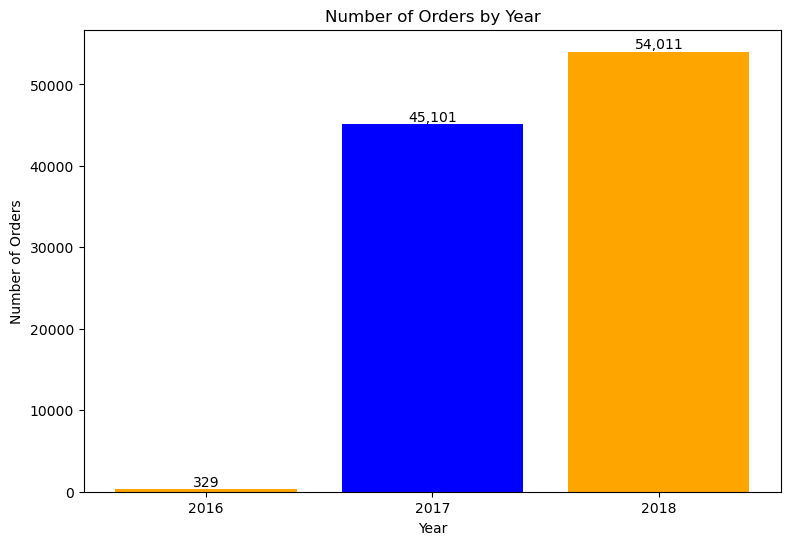

In [146]:
# Plot the number of orders by year
plt.figure(figsize=(9, 6))

bars = plt.bar(
    orders_by_year.index.astype(str),
    orders_by_year.values,
    color=["orange", "blue", "orange"]
)

plt.title("Number of Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The yearly order distribution shows how the number of orders changed over the available years.

- 2016 recorded very few orders because the dataset contains only a limited number of orders from that year.
- Order volume increased substantially in 2017.
- 2018 recorded the highest number of orders among the available years.
- The large increase from 2016 to 2017 indicates strong growth in the number of orders during the observed period.

**Business Insight:** The business experienced significant growth in order activity after 2016. However, yearly comparisons should consider that the dataset does not cover the same number of months for every year.

### Monthly Order Trend

In [147]:
# Count unique orders for each month
orders_by_month = (
    orders
    .groupby("order_month")["order_id"]
    .nunique()
)

orders_by_month

order_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64

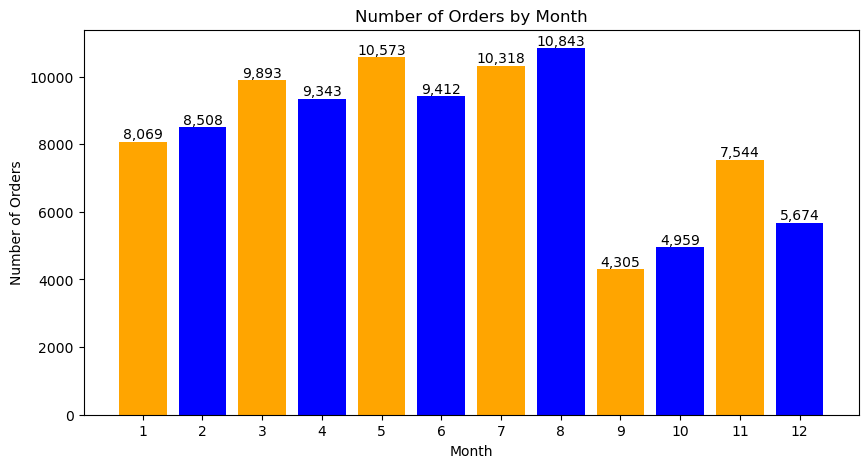

In [148]:
# Create monthly order chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    orders_by_month.index.astype(str),
    orders_by_month.values,
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Number of Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The monthly order trend shows how the number of orders varies across different months.

- **August recorded the highest number of orders:** 10,843.
- **May recorded the second-highest number of orders:** 10,573.
- March and July also recorded relatively high order volumes.
- September had the lowest order volume at **4,305 orders**.
- Order volume varies considerably across the months, with higher activity during some months and lower activity during others.

**Business Insight:** Monthly order volume can help the business plan inventory, seller capacity, logistics, and customer support resources according to periods of higher or lower demand.

### Monthly Sales / Revenue

In [149]:
# Calculate total recorded payment value for each month
monthly_revenue = (
    orders
    .groupby("order_month")["order_total_value"]
    .sum()
)

monthly_revenue

order_month
1     1253492.22
2     1284371.35
3     1609515.72
4     1578573.51
5     1746900.97
6     1535156.88
7     1658923.67
8     1696821.64
9      732454.23
10     839358.03
11    1194882.80
12     878421.10
Name: order_total_value, dtype: float64

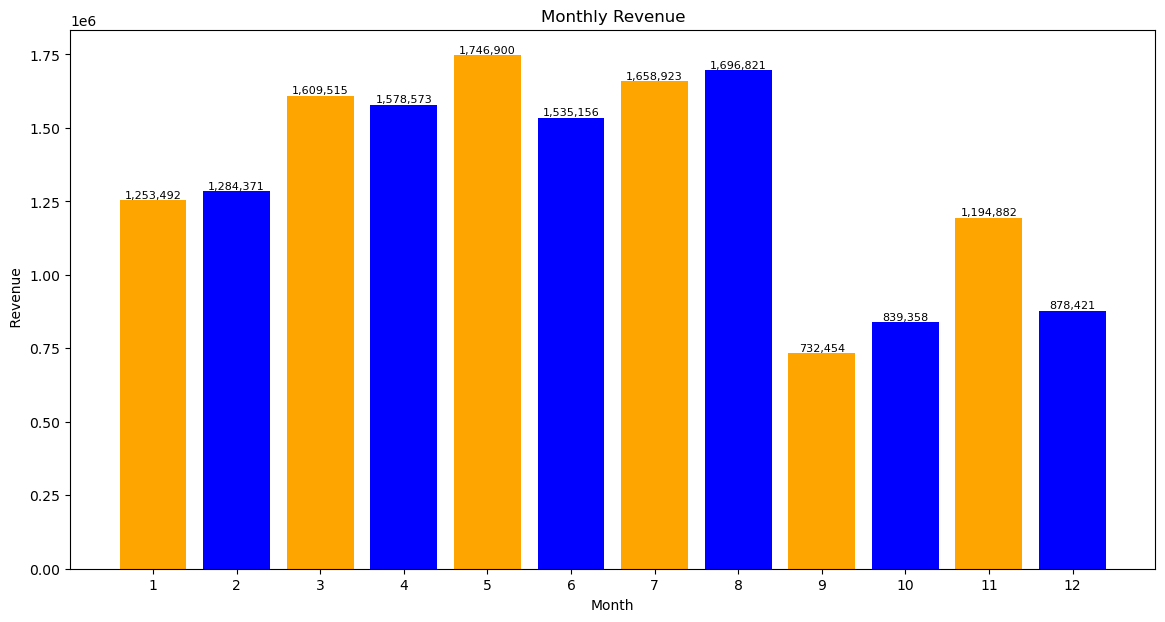

In [150]:
plt.figure(figsize=(14, 7))

bars = plt.bar(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel(" Revenue")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,.0f}",
        ha="center",
        va="bottom",
         fontsize=8
    )

plt.show()

### Interpretation

The monthly revenue analysis shows how the total order value changed across the months.

- May generated the highest revenue at approximately ₹1.75 million.
- August generated the second-highest revenue at approximately ₹1.70 million.
- September recorded relatively low revenue compared with the high-revenue months.
- Revenue does not always follow exactly the same pattern as order volume because order value also depends on the value of individual orders.

**Business Insight:** Revenue performance varies across months. The business should consider both order volume and average order value when evaluating monthly performance.

In [151]:
customer_type_counts = (
    customer_analysis["customer_type"]
    .value_counts()
)

customer_type_counts

customer_type
One-time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64

In [152]:
customer_type_percentage = (
    customer_type_counts / customer_type_counts.sum() * 100
).round(2)

customer_type_percentage

customer_type
One-time Customer    96.88
Repeat Customer       3.12
Name: count, dtype: float64

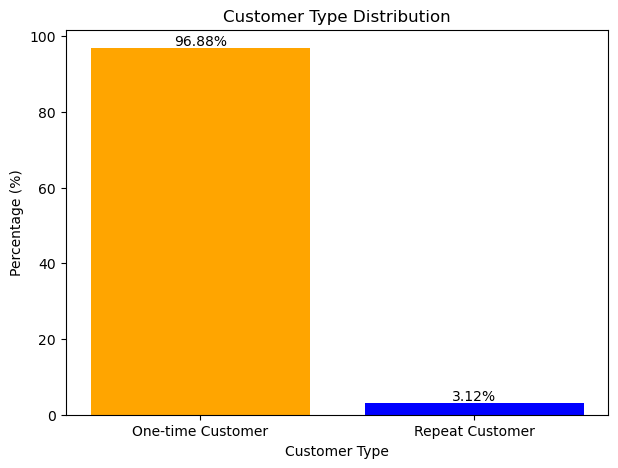

In [153]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    customer_type_percentage.index,
    customer_type_percentage.values,
    color=["orange", "blue"]
)

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Percentage (%)")

# Add percentage labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The customer analysis separates customers into one-time and repeat customers based on their number of orders.

- One-time customers account for approximately 96.88% of customers.
- Repeat customers account for approximately 3.12%.
- Therefore, the majority of customers placed only one order during the observed period.

**Business Insight:** The low proportion of repeat customers indicates a potential customer-retention opportunity. Increasing repeat purchases could increase customer lifetime value.

### Customer Spending Distribution

In [154]:
customer_analysis["total_spent"].describe()

count    96096.000000
mean       166.592492
std        231.428332
min          0.000000
25%         63.120000
50%        108.000000
75%        183.530000
max      13664.080000
Name: total_spent, dtype: float64

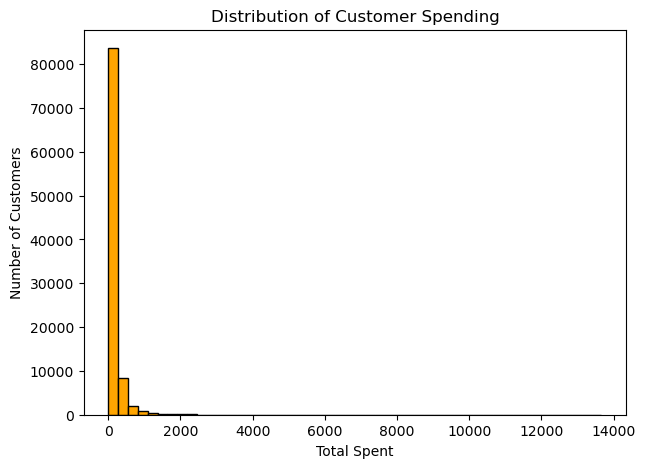

In [155]:
plt.figure(figsize=(7, 5))

plt.hist(
    customer_analysis["total_spent"],
    bins=50,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The customer spending distribution shows the amount spent by individual customers.

- The distribution is strongly right-skewed.
- Most customers have relatively low total spending.
- A small number of customers have substantially higher spending.
- The maximum customer spending is much higher than the median.

**Business Insight:** Customer value is unevenly distributed. The business can analyze high-value customers separately from the majority of lower-spending customers.

In [156]:
customer_type_spending = (
    customer_analysis
    .groupby("customer_type")["total_spent"]
    .mean()
    .round(2)
)

customer_type_spending

customer_type
One-time Customer    161.82
Repeat Customer      314.99
Name: total_spent, dtype: float64

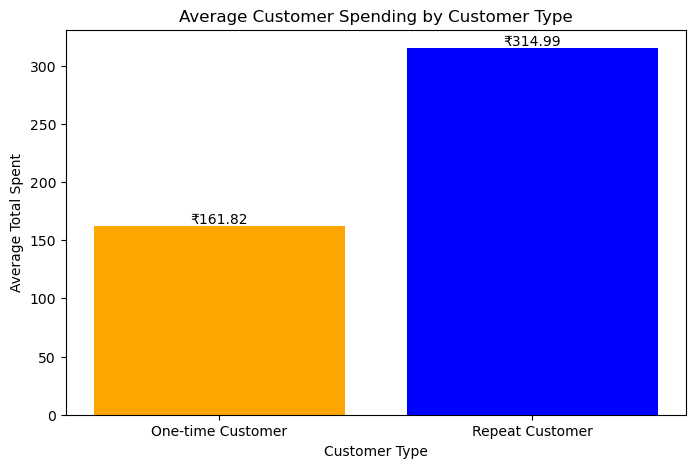

In [157]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_type_spending.index,
    customer_type_spending.values,
    color=["orange", "blue"]
)

plt.title("Average Customer Spending by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Total Spent")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The average spending differs between one-time and repeat customers.

- **One-time customers** spend an average of approximately **₹161.82**.
- **Repeat customers** spend an average of approximately **₹314.99**.
- Repeat customers therefore have an average spending level that is substantially higher than one-time customers.

**Business Insight:** Repeat customers represent a small portion of the customer base but show higher average spending. This highlights customer retention as an important area for further business analysis.

In [158]:
# Count customers by number of orders
customer_order_frequency = (
    customer_analysis["total_orders"]
    .value_counts()
    .sort_index()
)

customer_order_frequency

total_orders
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

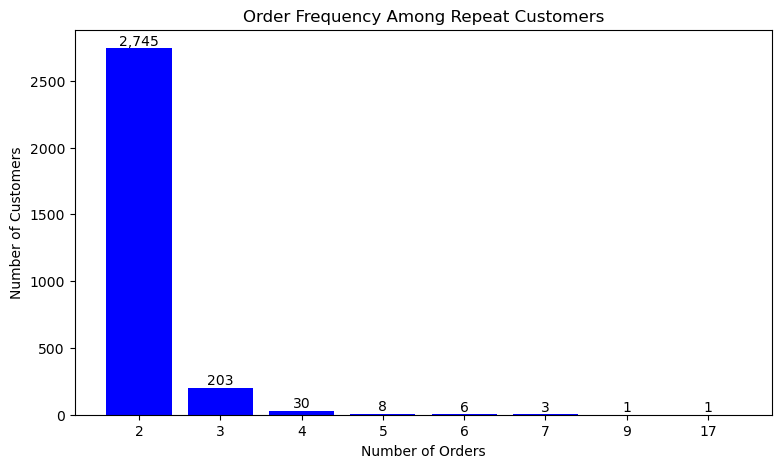

In [159]:
# Show order frequency for repeat customers
repeat_order_frequency = customer_order_frequency[
    customer_order_frequency.index > 1
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    repeat_order_frequency.index.astype(str),
    repeat_order_frequency.values,
    color="blue"
)

plt.title("Order Frequency Among Repeat Customers")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The order frequency among repeat customers shows that most repeat customers place only a small number of additional orders.

- **2 orders:** 2,745 customers
- **3 orders:** 203 customers
- **4 orders:** 30 customers
- Only a very small number of customers place 5 or more orders.
- One customer placed **17 orders**, representing an extreme but valid high-frequency customer.

**Business Insight:** Although repeat customers are relatively few, most repeat customers make only one additional purchase. This indicates an opportunity to improve long-term customer retention and encourage customers to purchase more frequently.

### Product Categories

In [160]:
# Find the top 10 categories by number of items sold
top_categories = (
    category_analysis
    .sort_values("total_items_sold", ascending=False)
    .head(10)
)

top_categories

,product_category_name,total_items_sold,total_sales,average_product_price
14,cama_mesa_banho,11115,1036988.68,93.296327
12,beleza_saude,9670,1258681.34,130.163531
33,esporte_lazer,8641,988048.97,114.344285
55,moveis_decoracao,8334,729762.49,87.564494
45,informatica_acessorios,7827,911954.32,116.513903
73,utilidades_domesticas,6964,632248.66,90.788148
67,relogios_presentes,5991,1205005.68,201.135984
71,telefonia,4545,323667.53,71.213978
41,ferramentas_jardim,4347,485256.46,111.630196
9,automotivo,4235,592720.11,139.957523


In [161]:
# Find the top 10 categories by total sales
top_categories_revenue = (
    category_analysis
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_categories_revenue

,product_category_name,total_items_sold,total_sales,average_product_price
12,beleza_saude,9670,1258681.34,130.163531
67,relogios_presentes,5991,1205005.68,201.135984
14,cama_mesa_banho,11115,1036988.68,93.296327
33,esporte_lazer,8641,988048.97,114.344285
45,informatica_acessorios,7827,911954.32,116.513903
55,moveis_decoracao,8334,729762.49,87.564494
27,cool_stuff,3796,635290.85,167.357969
73,utilidades_domesticas,6964,632248.66,90.788148
9,automotivo,4235,592720.11,139.957523
41,ferramentas_jardim,4347,485256.46,111.630196


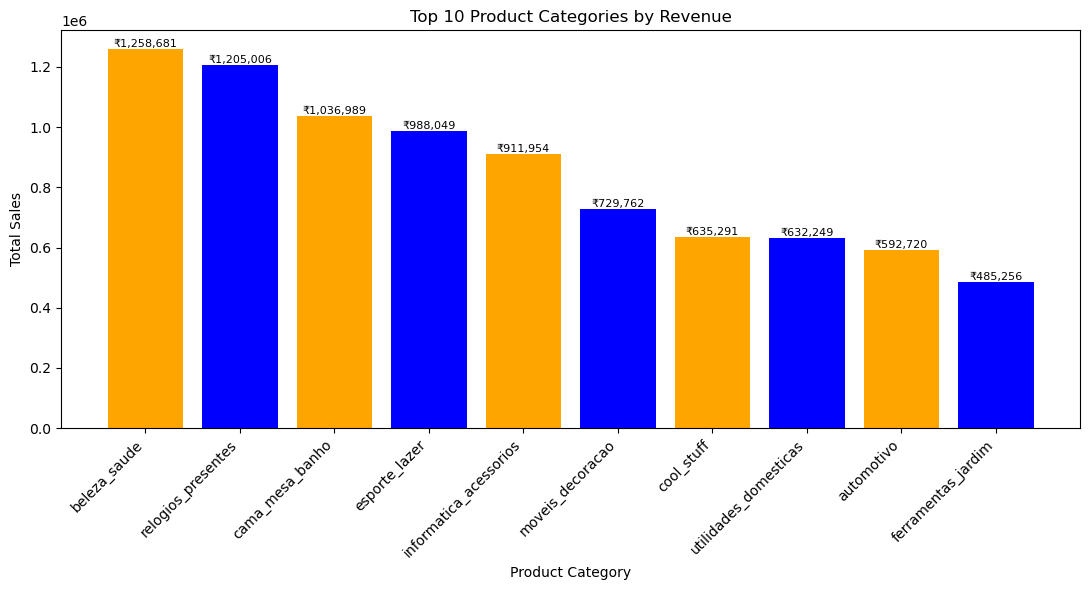

In [162]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_categories_revenue["product_category_name"],
    top_categories_revenue["total_sales"],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Interpretation

The top product categories by revenue show that sales performance is influenced by both demand volume and product price.

- **Beleza_Saude** generated the highest revenue at approximately **₹1.26 million**.
- **Relogios_Presentes** generated approximately **₹1.21 million** despite selling fewer items than some higher-volume categories.
- **Cama_Mesa_Banho** sold the highest number of items among these categories (**11,115**) and generated approximately **₹1.04 million**.
- **Esporte_Lazer** and **Informatica_Acessorios** also generated substantial revenue.
- The results show that **high sales volume does not always mean the highest revenue**, because average product price also affects total sales.

**Business Insight:** Product categories should be evaluated using both sales volume and revenue. High-volume categories can support demand-driven strategies, while higher-revenue categories may provide opportunities for premium products and revenue growth.

In [163]:
# Find the top 10 sellers by total sales
top_sellers = (
    seller_analysis
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_sellers

,seller_id,total_items_sold,total_orders,total_sales,average_order_value,items_per_order
857,4869f7a5dfa277a7dca6462dcf3b52b2,1156,1132,229472.63,202.714337,1.021201
1013,53243585a1d6dc2643021fd1853d8905,410,358,222776.05,622.279469,1.145251
881,4a3ca9315b744ce9f8e9374361493884,1987,1806,200472.92,111.003832,1.100221
3024,fa1c13f2614d7b5c4749cbc52fecda94,586,585,194042.03,331.695778,1.001709
1535,7c67e1448b00f6e969d365cea6b010ab,1364,982,187923.89,191.368523,1.389002
1560,7e93a43ef30c4f03f38b393420bc753a,340,336,176431.87,525.094851,1.011905
2643,da8622b14eb17ae2831f4ac5b9dab84a,1551,1314,160236.57,121.945639,1.180365
1505,7a67c85e85bb2ce8582c35f2203ad736,1171,1160,141745.53,122.194422,1.009483
192,1025f0e2d44d7041d6cf58b6550e0bfa,1428,915,138968.55,151.878197,1.560656
1824,955fee9216a65b617aa5c0531780ce60,1499,1287,135171.70,105.028516,1.164724


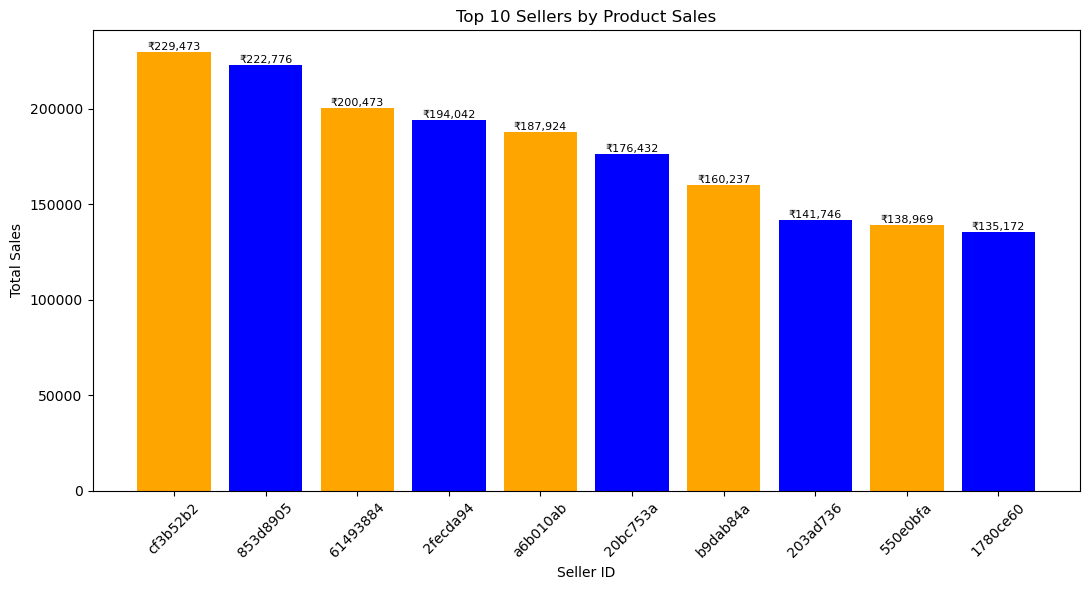

In [164]:
plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_sellers["seller_id"].str[-8:],
    top_sellers["total_sales"],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 Sellers by Product Sales")
plt.xlabel("Seller ID")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Interpretation

The seller analysis shows that sellers can generate similar sales through different combinations of order volume and average order value.

- The highest-sales seller generated approximately **₹229,473** from **1,132 orders**.
- Another seller generated approximately **₹222,776** from only **358 orders**, resulting in a much higher average order value of approximately **₹622**.
- Some sellers have high item and order volumes but relatively lower average order values.
- Items per order also vary between sellers.

**Business Insight:** Seller performance should not be evaluated using total sales alone. Order volume, average order value, and items per order provide additional context for understanding seller performance.

### Payment Methods

In [165]:
payment_type_counts = payments["payment_type"].value_counts()

payment_type_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

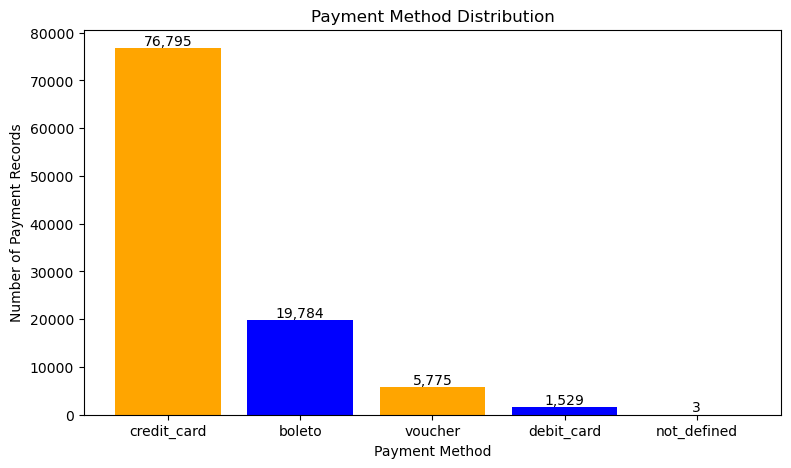

In [166]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    payment_type_counts.index,
    payment_type_counts.values,
    color=["orange", "blue", "orange", "blue", "orange"]
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payment Records")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The payment-method analysis shows the number of payment records associated with each payment method.

- Credit cards are the most frequently used payment method.
- Boleto is the second most frequently used method.
- Voucher and debit card payments represent smaller proportions of payment records.
- The `not_defined` category contains very few records.

**Business Insight:** Credit cards are the dominant payment method in the dataset. Payment infrastructure and customer experience should therefore support the most frequently used payment methods effectively.

In [167]:
payment_value_by_type = (
    payments
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

payment_value_by_type

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

In [168]:
# Calculate payment count percentage
payment_count_percentage = (
    payment_type_counts / payment_type_counts.sum() * 100
)

# Calculate payment value percentage
payment_value_percentage = (
    payment_value_by_type / payment_value_by_type.sum() * 100
)

# Combine both metrics
payment_comparison = pd.DataFrame({
    "count_percentage": payment_count_percentage,
    "value_percentage": payment_value_percentage
}).fillna(0)

payment_comparison.round(2)

,count_percentage,value_percentage
payment_type,,
credit_card,73.92,78.34
boleto,19.04,17.92
voucher,5.56,2.37
debit_card,1.47,1.36
not_defined,0.00,0.00


### Interpretation

The payment method comparison shows the difference between payment frequency and the share of total payment value.

- **Credit cards** account for **73.92% of payment records** and **78.34% of payment value**.
- **Boleto** accounts for **19.04% of payment records** and **17.92% of payment value**.
- **Voucher** represents **5.56% of payment records** but only **2.37% of payment value**.
- Debit card payments represent a relatively small share of both payment records and payment value.
- The difference between count share and value share shows that payment methods can have different average transaction values.

**Business Insight:** Credit cards are the dominant payment method in both usage and payment value. Payment performance should therefore be monitored by considering both transaction frequency and monetary contribution.

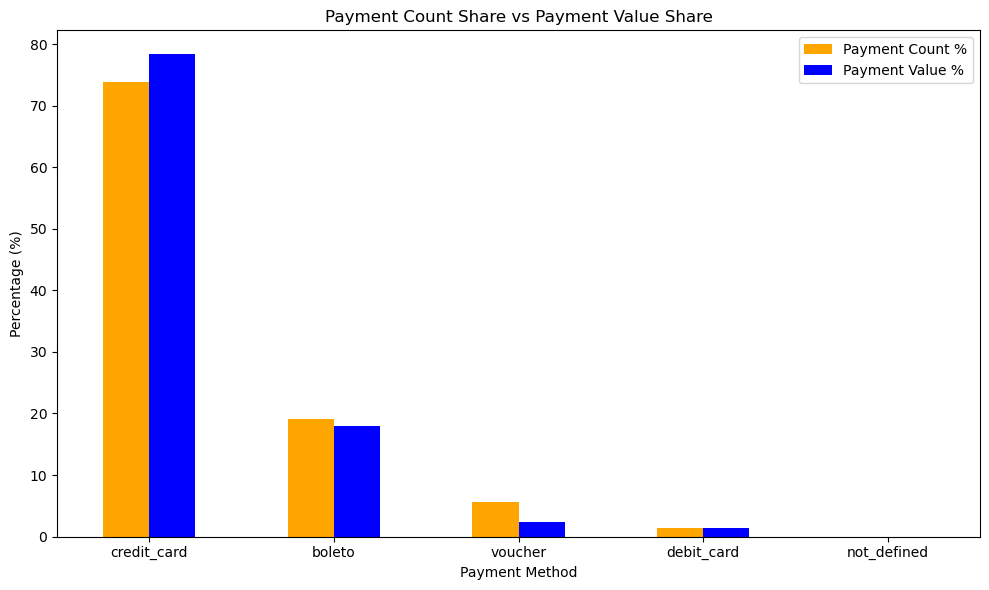

In [169]:
payment_comparison.plot(
    kind="bar",
    figsize=(10, 6),
    color=["orange", "blue"]
)

plt.title("Payment Count Share vs Payment Value Share")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Payment Count %", "Payment Value %"]
)

plt.tight_layout()
plt.show()

In [170]:
average_payment_by_type = (
    payments
    .groupby("payment_type")["payment_value"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

average_payment_by_type

payment_type
credit_card    163.32
boleto         145.03
debit_card     142.57
voucher         65.70
not_defined      0.00
Name: payment_value, dtype: float64

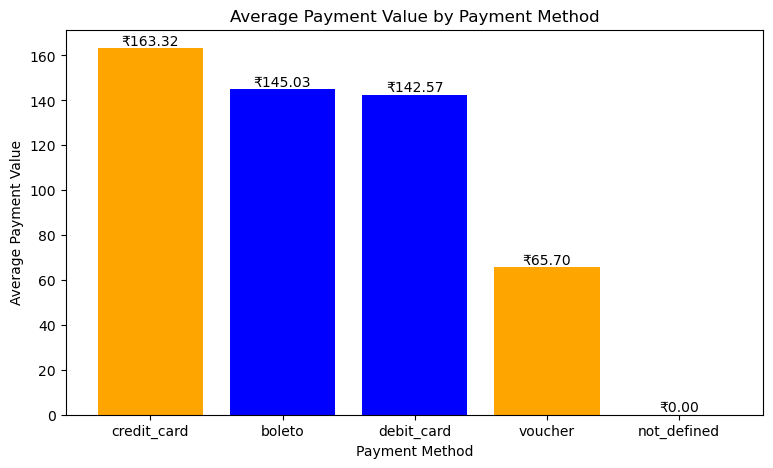

In [171]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    average_payment_by_type.index,
    average_payment_by_type.values,
    color=["orange", "blue", "blue", "orange", "blue"]
)

plt.title("Average Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Payment Value")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{bar.get_height():,.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

### Delivery Performance

In [172]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

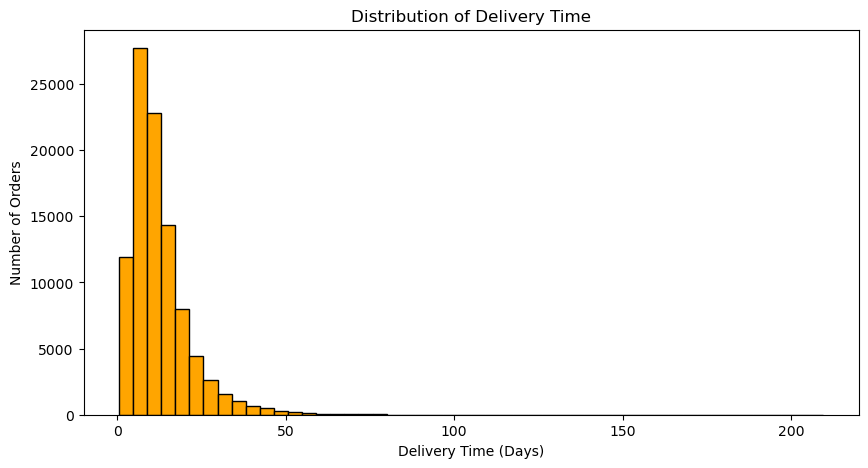

In [173]:
plt.figure(figsize=(10, 5))

plt.hist(
    orders["delivery_days"].dropna(),
    bins=50,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

### Interpretation

The delivery-time distribution is right-skewed, indicating that most orders were delivered within a relatively shorter time, while a smaller number of orders took substantially longer.

- Mean delivery time: **12.56 days**
- Median delivery time: **10.22 days**
- 75% of orders were delivered within approximately **15.72 days**
- A small number of deliveries took much longer, creating a long right tail.

**Business Insight:** The median delivery time is considerably lower than the mean because a relatively small number of very delayed deliveries increase the average. These delayed orders should be investigated because they can negatively affect customer experience and operational performance.

In [174]:
Q1 = orders["delivery_days"].quantile(0.25)
Q3 = orders["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 6.766403356481481
Q3: 15.720326967592593
IQR: 8.953923611111112
Lower bound: -6.664482060185186
Upper bound: 29.15121238425926


In [175]:
delivery_outliers = orders[
    orders["delivery_days"] > upper_bound
]

print("Delivery outliers:", len(delivery_outliers))
print(
    "Percentage of deliveries that are outliers:",
    round(len(delivery_outliers) / orders["delivery_days"].notna().sum() * 100, 2),
    "%"
)

Delivery outliers: 4899
Percentage of deliveries that are outliers: 5.08 %


In [176]:
delivery_outliers["delivery_days"].describe()

count    4899.000000
mean       40.783683
std        16.205274
min        29.153322
25%        32.142616
50%        36.153600
75%        43.724716
max       209.628611
Name: delivery_days, dtype: float64

In [177]:
delivery_outliers[
    ["order_id", "order_status", "delivery_days"]
].sort_values(
    "delivery_days",
    ascending=False
).head(10)

,order_id,order_status,delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,208.351759
61610,440d0d17af552815d15a9e41abe49359,delivered,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,194.850174
89130,285ab9426d6982034523a855f55a885e,delivered,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,194.049583
11399,47b40429ed8cce3aee9199792275433f,delivered,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,188.134618
68769,c27815f7e3dd0b926b58552628481575,delivered,187.743843


In [178]:
order_review_score = (
    reviews
    .groupby("order_id")["review_score"]
    .mean()
    .reset_index()
)

order_review_score.head()

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [179]:
delivery_review = orders[
    ["order_id", "delivery_days"]
].merge(
    order_review_score,
    on="order_id",
    how="inner"
)

print("Rows after merge:", len(delivery_review))
print("Unique orders:", delivery_review["order_id"].nunique())

Rows after merge: 98673
Unique orders: 98673


In [180]:
delivery_review[
    ["delivery_days", "review_score"]
].corr()

,delivery_days,review_score
delivery_days,1.000000,-0.334302
review_score,-0.334302,1.000000


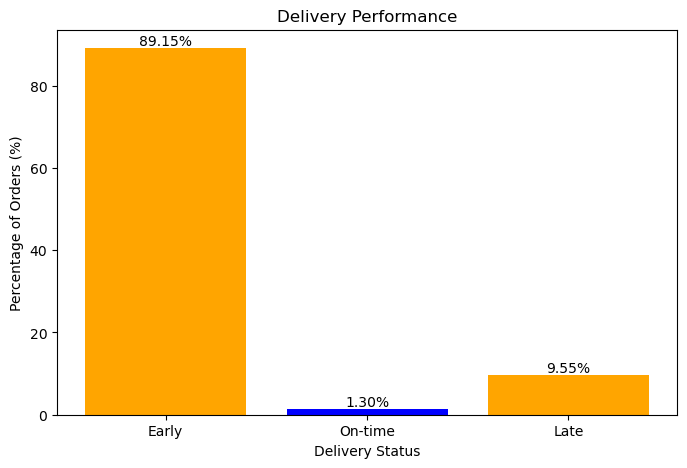

In [181]:
delivery_status = pd.Series({
    "Early"  :    89.15,
    "On-time" :    1.30,
    "Late"     :   9.55
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    delivery_status.index,
    delivery_status.values,
    color=["orange", "blue", "orange"]
)

plt.title("Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage of Orders (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The delivery performance analysis shows that most orders were delivered earlier than the estimated delivery date.

- **Early deliveries:** 89.15% of orders
- **On-time deliveries:** 1.30% of orders
- **Late deliveries:** 9.55% of orders
- Late deliveries represent a meaningful portion of total orders.
- Delivery performance is also associated with customer satisfaction, as late deliveries have substantially lower review scores.

**Business Insight:** Delivery reliability is an important business area because late deliveries are associated with lower customer satisfaction. Monitoring delayed orders can help identify opportunities to improve the customer experience.

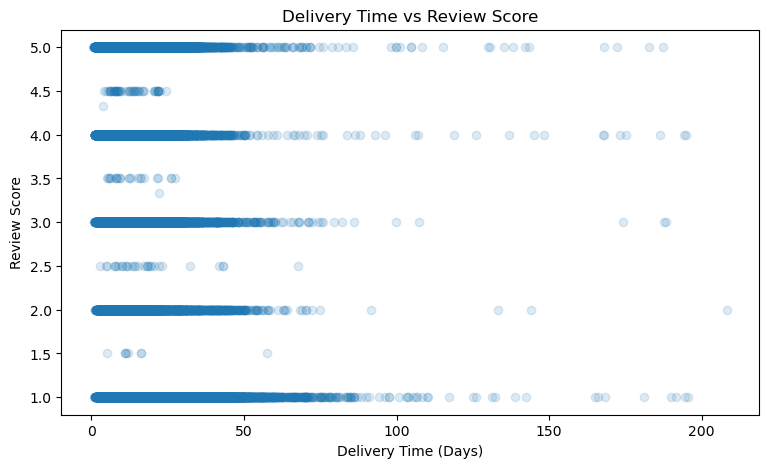

In [182]:
plt.figure(figsize=(9, 5))

plt.scatter(
    delivery_review["delivery_days"],
    delivery_review["review_score"],
    alpha=0.15
)

plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Review Score")

plt.show()

### Interpretation

The scatter plot examines the relationship between delivery time and customer review scores.

- The correlation between delivery time and review score is approximately **-0.334**.
- This indicates a **moderate negative relationship** between the two variables.
- As delivery time increases, review scores tend to decrease.
- This relationship represents **association, not causation**.

**Business Insight:** Delivery time is an important factor associated with customer satisfaction. Orders with longer delivery times tend to receive lower review scores, indicating that delivery performance should be considered when improving the customer experience.

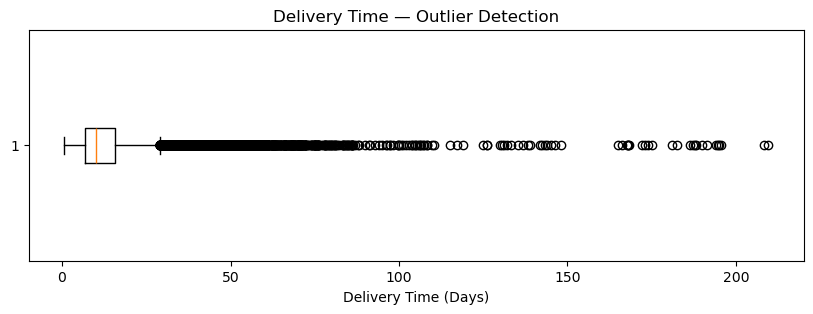

In [183]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    orders["delivery_days"].dropna(),
    vert=False
)

plt.title("Delivery Time — Outlier Detection")
plt.xlabel("Delivery Time (Days)")

plt.show()

### Interpretation

The boxplot identifies unusually long delivery times using the IQR method.

- Q1 is approximately **6.77 days**.
- Q3 is approximately **15.72 days**.
- The IQR is approximately **8.95 days**.
- The upper outlier boundary is approximately **29.15 days**.
- **4,899 deliveries (5.08%)** are classified as statistical outliers.
- Some extreme deliveries took more than **180 days**.

**Business Insight:** These outliers should not automatically be removed because they may represent genuine operational events. Instead, they should be investigated to understand the reasons for extremely long delivery times.

### Review

In [184]:
review_score_counts = reviews["review_score"].value_counts().sort_index()

review_score_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [185]:
review_percentage = (
    review_score_counts / review_score_counts.sum() * 100
).round(2)

review_percentage

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: count, dtype: float64

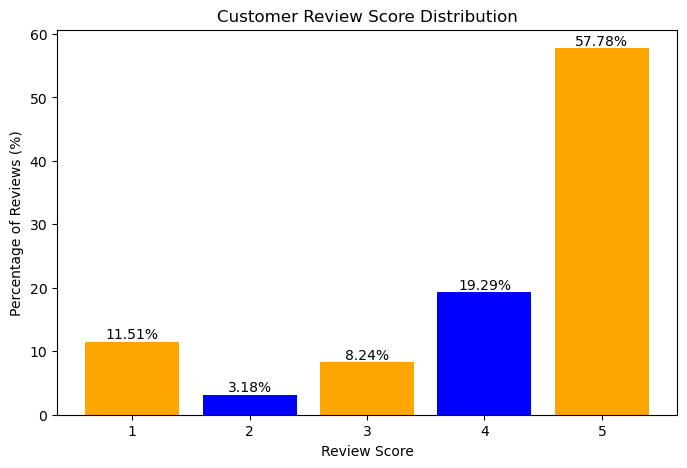

In [186]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    review_percentage.index,
    review_percentage.values,
    color=["orange", "blue", "orange", "blue", "orange"]
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Percentage of Reviews (%)")

plt.xticks([1, 2, 3, 4, 5])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Interpretation

The review score distribution shows that customer feedback is concentrated toward the higher ratings.

- **5-star reviews:** 57.78%
- **4-star reviews:** 19.29%
- **3-star reviews:** 8.24%
- **2-star reviews:** 3.18%
- **1-star reviews:** 11.51%
- Overall, **77.07% of reviews are 4 or 5 stars**.
- **14.69% of reviews are 1 or 2 stars**.

**Business Insight:** Most customers gave positive ratings, but the presence of low-rated reviews indicates that there is still a group of customers experiencing dissatisfaction. These lower-rated orders can be examined further using delivery, product, seller, and payment-related factors.

In [187]:
average_review_score = reviews["review_score"].mean()

print("Average Review Score:", round(average_review_score, 2))

Average Review Score: 4.09


In [188]:
orders["delivery_status"] = np.where(
    orders["delivery_delay_days"] < 0,
    "Early",
    np.where(
        orders["delivery_delay_days"] == 0,
        "On-time",
        "Late"
    )
)

In [189]:
orders["delivery_status"].value_counts()

delivery_status
Early      88649
Late        9500
On-time     1292
Name: count, dtype: int64

In [190]:
review_by_delivery = (
    delivery_review
    .merge(
        orders[["order_id", "delivery_status"]],
        on="order_id",
        how="left"
    )
    .groupby("delivery_status")["review_score"]
    .agg(["count", "mean"])
    .round(2)
)

review_by_delivery

,count,mean
delivery_status,,
Early,88168,4.29
Late,9225,2.11
On-time,1280,4.04


In [191]:
orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

In [192]:
orders.loc[
    (orders["delivery_delay_days"] > 0) &
    (orders["delivery_days"].isna()),
    ["order_id", "delivery_delay_days", "delivery_days"]
].head(10)

,order_id,delivery_delay_days,delivery_days


In [193]:
delivery_status_percentage = (
    orders["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_status_percentage

delivery_status
Early      89.15
Late        9.55
On-time     1.30
Name: proportion, dtype: float64

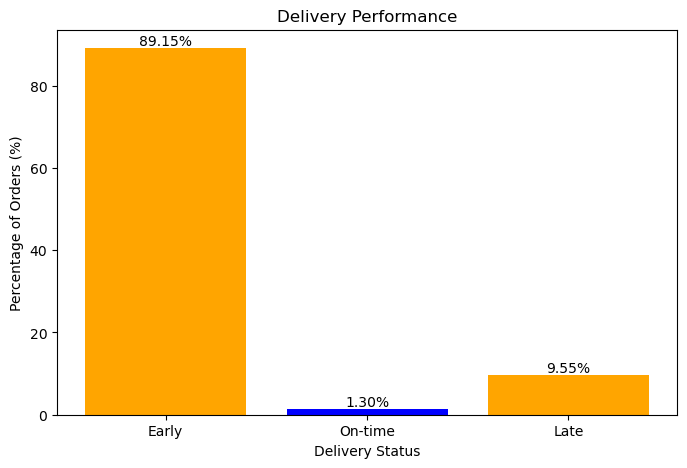

In [194]:
delivery_status_percentage = (
    orders["delivery_status"]
    .value_counts(normalize=True)
    .reindex(["Early", "On-time", "Late"])
    .mul(100)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    delivery_status_percentage.index,
    delivery_status_percentage.values,
    color=["orange", "blue", "orange"]
)

plt.title("Delivery Performance")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage of Orders (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha="center",
        va="bottom"
    )

plt.show()

### Order Status

In [195]:
order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [196]:
order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

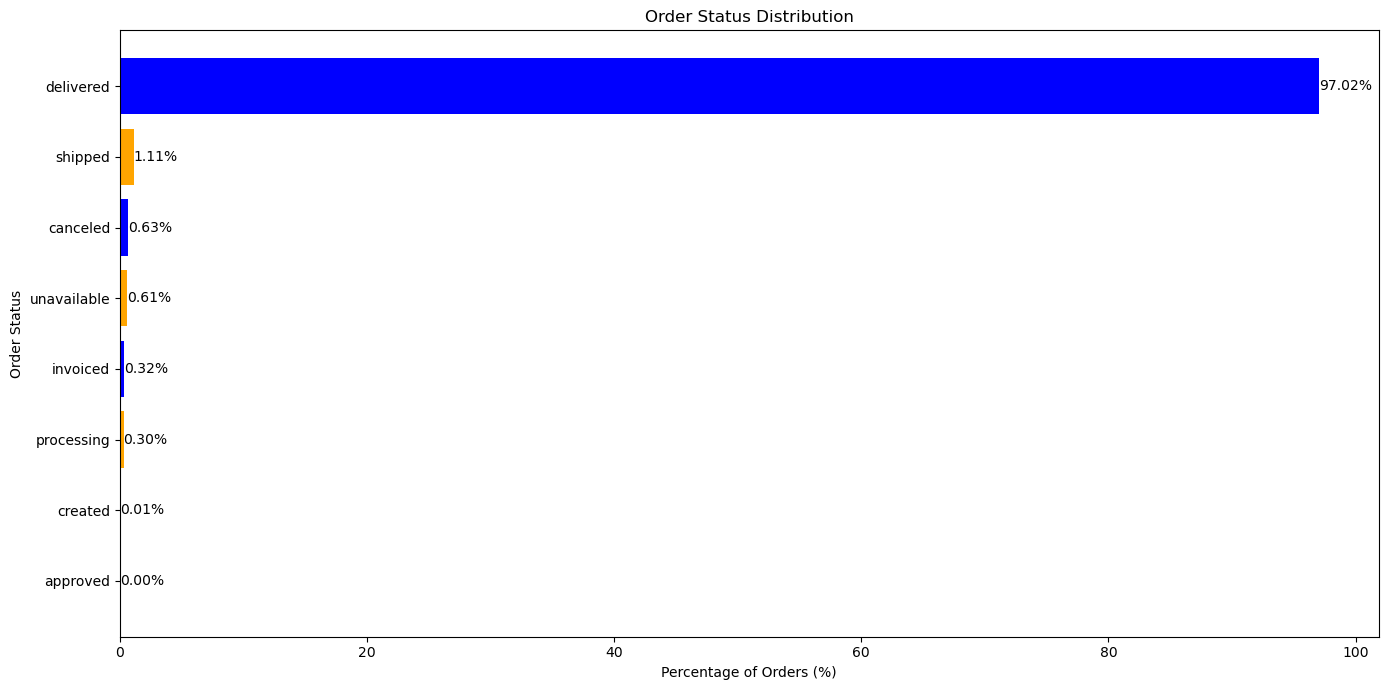

In [197]:
plt.figure(figsize=(14, 7))

bars = plt.barh(
    order_status_percentage.index[::-1],
    order_status_percentage.values[::-1],
    color=["orange", "blue", "orange", "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Order Status Distribution")
plt.xlabel("Percentage of Orders (%)")
plt.ylabel("Order Status")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

The order status distribution shows that the vast majority of orders were successfully delivered.

- **Delivered:** 96,478 orders
- **Shipped:** 1,107 orders
- **Cancelled:** 625 orders
- **Unavailable:** 609 orders
- The remaining orders are distributed across invoiced, processing, created, and approved statuses.

**Business Insight:** The high number of delivered orders indicates that most orders completed successfully. Cancelled and unavailable orders form a relatively small portion of the dataset and can be examined separately to understand potential operational issues.

In [198]:
orders["order_total_value"].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: order_total_value, dtype: float64

In [199]:
Q1_order = orders["order_total_value"].quantile(0.25)
Q3_order = orders["order_total_value"].quantile(0.75)

IQR_order = Q3_order - Q1_order

upper_order_bound = Q3_order + 1.5 * IQR_order

print("Q1:", Q1_order)
print("Q3:", Q3_order)
print("IQR:", IQR_order)
print("Upper bound:", upper_order_bound)

Q1: 62.01
Q3: 176.97
IQR: 114.96000000000001
Upper bound: 349.40999999999997


In [200]:
order_value_outliers = orders[
    orders["order_total_value"] > upper_order_bound
]

print("High-value outliers:", len(order_value_outliers))

print(
    "Percentage of orders:",
    round(
        len(order_value_outliers)
        / orders["order_total_value"].notna().sum() * 100,
        2
    ),
    "%"
)

High-value outliers: 7866
Percentage of orders: 7.91 %


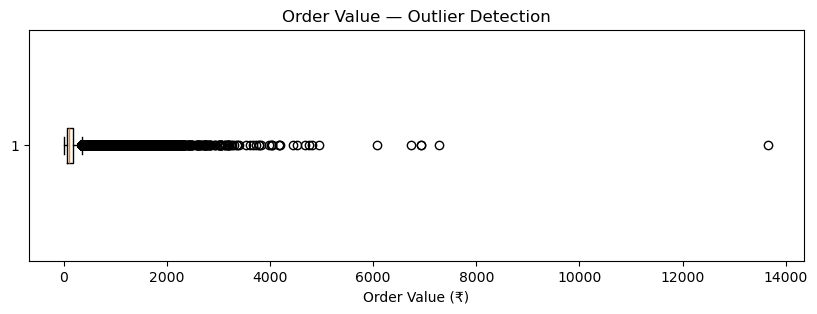

In [201]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    orders["order_total_value"].dropna(),
    vert=False
)

plt.title("Order Value — Outlier Detection")
plt.xlabel("Order Value (₹)")

plt.show()


### Interpretation

The order-value distribution shows that most orders have relatively low values, while a smaller number of orders have much higher values.

- The **median order value** is approximately **₹105.29**.
- The **mean order value** is approximately **₹160.99**.
- The difference between the mean and median indicates a **right-skewed distribution**.
- The IQR method identifies **7,866 high-value orders**, representing approximately **7.91% of orders**.
- These high-value observations should not automatically be removed because they may represent genuine customer purchases.

**Business Insight:** High-value orders represent an important customer segment that can be analyzed separately to understand premium purchases, customer value, and revenue contribution.

In [202]:
product_sales = (
    order_items
    .groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64

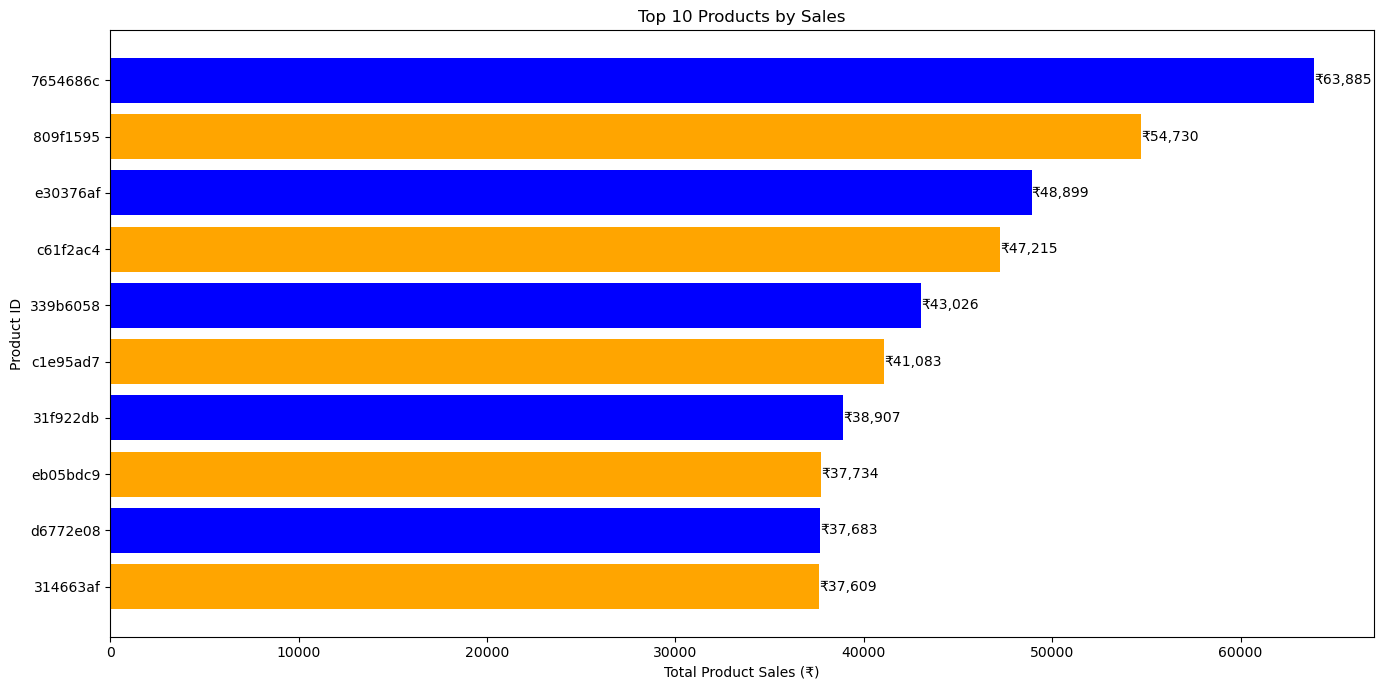

In [203]:
top_products = product_sales.head(10)

plt.figure(figsize=(14, 7))

bars = plt.barh(
    top_products.index[::-1].str[-8:],
    top_products.values[::-1],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Product Sales (₹)")
plt.ylabel("Product ID")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"₹{bar.get_width():,.0f}",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

The top-product analysis shows that product sales can be influenced by both the number of items sold and the average selling price.

- The highest-selling product generated approximately **₹63,885** in product sales.
- Some products generated high sales through relatively high sales volume.
- Other products generated similar sales with fewer units because of their higher average prices.
- For example, one product generated approximately **₹48,899** from only **35 items**, while another generated approximately **₹37,609** from **527 items**.

**Business Insight:** Product performance should be evaluated using both sales value and sales volume. This helps distinguish high-volume products from high-value products and supports better product-level analysis.

In [204]:
product_analysis = (
    order_items
    .groupby("product_id")
    .agg(
        items_sold=("product_id", "count"),
        total_product_sales=("price", "sum")
    )
    .reset_index()
)

product_analysis["average_price"] = (
    product_analysis["total_product_sales"]
    / product_analysis["items_sold"]
)

product_analysis.sort_values(
    "total_product_sales",
    ascending=False
).head(10)

,product_id,items_sold,total_product_sales,average_price
24086,bb50f2e236e5eea0100680137654686c,195,63885.00,327.615385
14068,6cdd53843498f92890544667809f1595,156,54730.20,350.834615
27613,d6160fb7873f184099d9bc95e30376af,35,48899.34,1397.124000
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.651633
19742,99a4788cb24856965c36a24e339b6058,488,43025.56,88.167131
8051,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60,149.936496
4996,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.876842
12351,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.950794
10867,53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.666935
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.364137


In [205]:
top_product_analysis = (
    product_analysis
    .sort_values("total_product_sales", ascending=False)
    .head(10)
)

top_product_analysis

,product_id,items_sold,total_product_sales,average_price
24086,bb50f2e236e5eea0100680137654686c,195,63885.00,327.615385
14068,6cdd53843498f92890544667809f1595,156,54730.20,350.834615
27613,d6160fb7873f184099d9bc95e30376af,35,48899.34,1397.124000
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.651633
19742,99a4788cb24856965c36a24e339b6058,488,43025.56,88.167131
8051,3dd2a17168ec895c781a9191c1e95ad7,274,41082.60,149.936496
4996,25c38557cf793876c5abdd5931f922db,38,38907.32,1023.876842
12351,5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.950794
10867,53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.666935
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.364137


In [206]:
customer_revenue = (
    customer_analysis
    .groupby("customer_type")["total_spent"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue

customer_type
One-time Customer    15064849.41
Repeat Customer        944022.71
Name: total_spent, dtype: float64

In [207]:
customer_count_percentage = (
    customer_analysis["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
)

customer_revenue_percentage = (
    customer_revenue / customer_revenue.sum() * 100
)

customer_comparison = pd.DataFrame({
    "Customer Share %": customer_count_percentage,
    "Revenue Share %": customer_revenue_percentage
})

customer_comparison

,Customer Share %,Revenue Share %
customer_type,,
One-time Customer,96.881244,94.103128
Repeat Customer,3.118756,5.896872


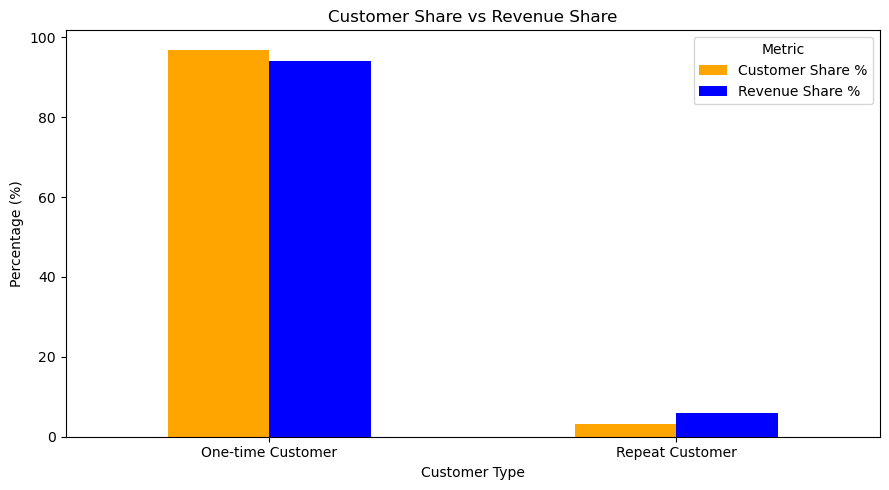

In [208]:
customer_comparison.plot(
    kind="bar",
    figsize=(9, 5),
    color=["orange", "blue"]
)

plt.title("Customer Share vs Revenue Share")
plt.xlabel("Customer Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Geographic

In [209]:
customer_state_orders = (
    customers["customer_state"]
    .value_counts()
)

customer_state_orders.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [210]:
customer_state_orders.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [211]:
state_percentage = (
    customer_state_orders.head(10)
    / customer_state_orders.sum()
    * 100
).round(2)

state_percentage

customer_state
SP    41.98
RJ    12.92
MG    11.70
RS     5.50
PR     5.07
SC     3.66
BA     3.40
DF     2.15
ES     2.04
GO     2.03
Name: count, dtype: float64

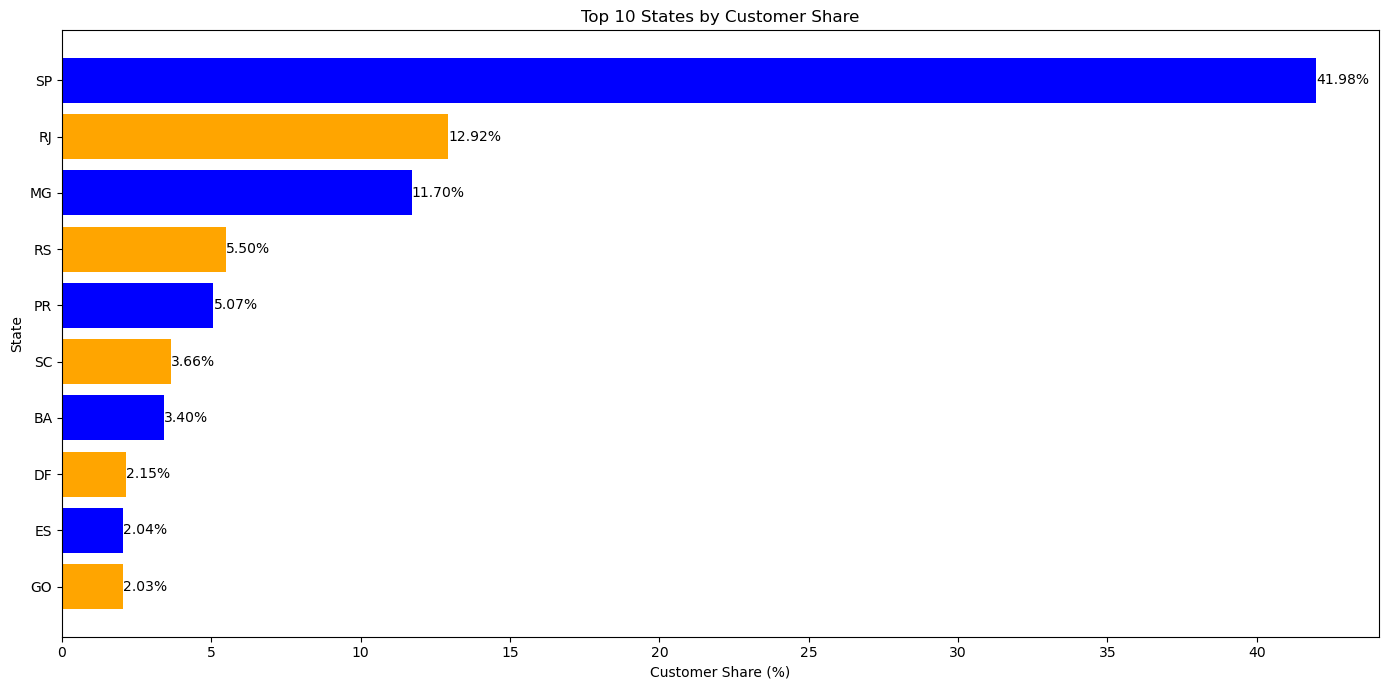

In [212]:
plt.figure(figsize=(14, 7))

bars = plt.barh(
    state_percentage.index[::-1],
    state_percentage.values[::-1],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 States by Customer Share")
plt.xlabel("Customer Share (%)")
plt.ylabel("State")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

The state-level revenue analysis shows that revenue is concentrated in a small number of Brazilian states.

- **São Paulo (SP)** contributes approximately **37.47% of total revenue**.
- **Rio de Janeiro (RJ)** contributes approximately **13.39%**.
- **Minas Gerais (MG)** contributes approximately **11.70%**.
- The remaining states contribute smaller individual shares of total revenue.
- The concentration of revenue broadly follows the concentration of customers across the major states.

**Business Insight:** Geographic revenue concentration can help the business understand its major markets and support decisions related to logistics, inventory planning, and regional market expansion.

In [213]:
state_revenue = (
    orders[
        ["order_id", "customer_id", "order_total_value"]
    ]
    .merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")["order_total_value"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: order_total_value, dtype: float64

In [214]:
print("Total states:", state_revenue.index.nunique())
print("Total revenue:", state_revenue.sum())

Total states: 27
Total revenue: 16008872.120000001


In [215]:
state_revenue_percentage = (
    state_revenue.head(10)
    / state_revenue.sum()
    * 100
).round(2)

state_revenue_percentage

customer_state
SP    37.47
RJ    13.39
MG    11.70
RS     5.57
PR     5.07
SC     3.89
BA     3.85
DF     2.22
GO     2.19
ES     2.04
Name: order_total_value, dtype: float64

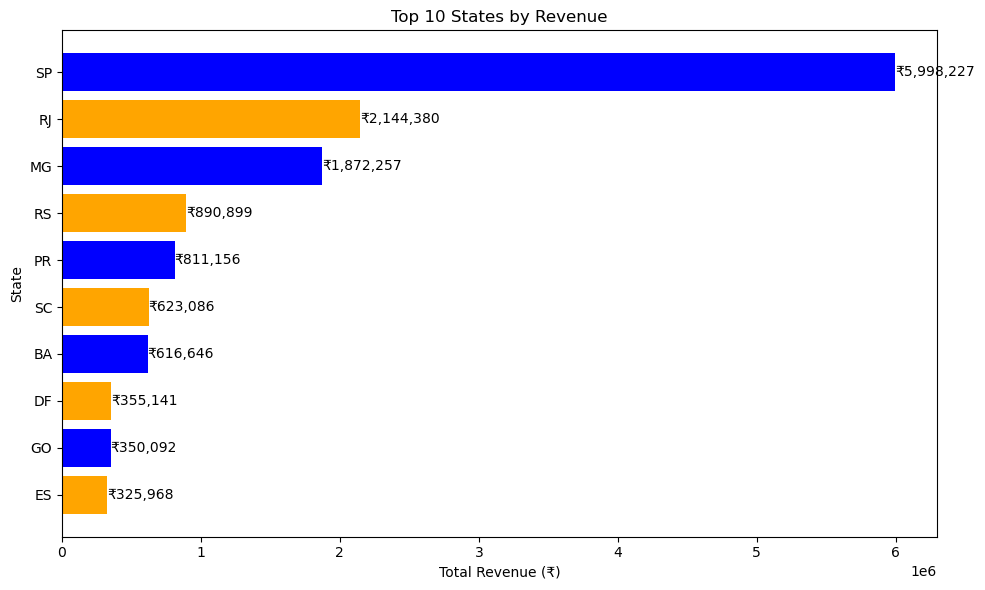

In [216]:
top_state_revenue = state_revenue.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_state_revenue.index[::-1],
    top_state_revenue.values[::-1],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 States by Revenue")
plt.xlabel("Total Revenue (₹)")
plt.ylabel("State")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"₹{bar.get_width():,.0f}",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

## Geographic Revenue Analysis

In [217]:
# Maping customer state to orders
orders_with_state = orders.merge(
    customers[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
)

print("Total orders:", len(orders_with_state))
print("Missing states:", orders_with_state["customer_state"].isna().sum())

Total orders: 99441
Missing states: 0


In [218]:
# Calculating revenue by state
state_revenue = (
    orders_with_state
    .groupby("customer_state")["order_total_value"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue.head(10)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
Name: order_total_value, dtype: float64

In [219]:
# calculating revenue share
state_revenue_percentage = (
    state_revenue.head(10)
    / state_revenue.sum()
    * 100
).round(2)

state_revenue_percentage

customer_state
SP    37.47
RJ    13.39
MG    11.70
RS     5.57
PR     5.07
SC     3.89
BA     3.85
DF     2.22
GO     2.19
ES     2.04
Name: order_total_value, dtype: float64

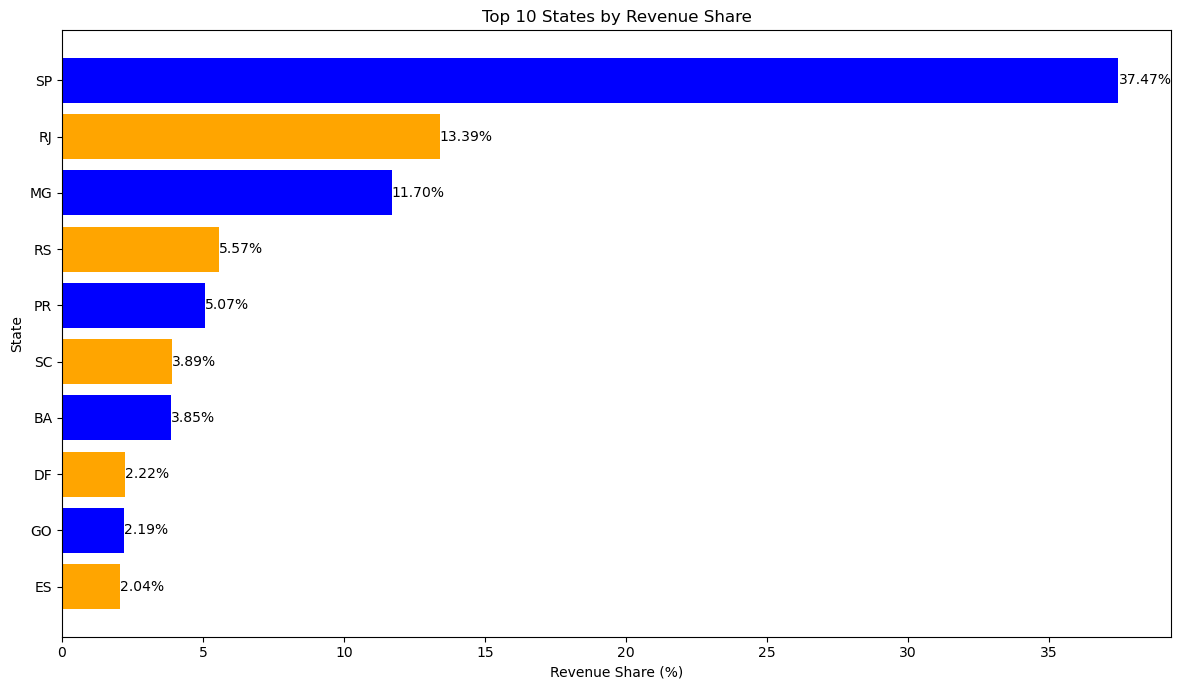

In [220]:
plt.figure(figsize=(12, 7))

bars = plt.barh(
    state_revenue_percentage.index[::-1],
    state_revenue_percentage.values[::-1],
    color=["orange", "blue", "orange", "blue", "orange",
           "blue", "orange", "blue", "orange", "blue"]
)

plt.title("Top 10 States by Revenue Share")
plt.xlabel("Revenue Share (%)")
plt.ylabel("State")

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        ha="left",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

The state-level revenue analysis compares the total order value generated from different customer states.

- São Paulo generates the highest revenue at approximately ₹6.0 million.
- Rio de Janeiro and Minas Gerais are the next major contributors.
- The revenue ranking broadly reflects the concentration of customers in these states.

**Business Insight:** The geographic concentration of revenue highlights the importance of major markets such as São Paulo, Rio de Janeiro, and Minas Gerais. Regional demand can be considered when planning logistics and future market expansion.

# EDA Summary

The exploratory data analysis identified several important patterns in the Olist e-commerce dataset.

- Order activity increased substantially during the observed period.
- Customer activity is highly concentrated among one-time customers.
- Repeat customers have higher average spending than one-time customers.
- Product category performance varies based on both sales volume and price.
- Credit cards are the dominant payment method.
- Most orders were delivered early, while late deliveries represented approximately 9.55% of orders.
- Longer delivery times are associated with lower customer review scores.
- Customer reviews are generally positive, with 4- and 5-star ratings representing the majority of reviews.
- Order and customer spending distributions are strongly right-skewed, with a relatively small number of high-value observations.
- Customer and revenue activity is concentrated in a few Brazilian states.

These findings provide the foundation for the statistical analysis and business analysis performed in the next sections.

## Statistical Analysis

In [221]:
numeric_analysis = customer_analysis[
    ["total_orders", "total_spent", "average_order_value"]
]

numeric_analysis.corr().round(2)

,total_orders,total_spent,average_order_value
total_orders,1.00,0.13,-0.01
total_spent,0.13,1.00,0.98
average_order_value,-0.01,0.98,1.00


In [222]:
# final check revenue consistency
print("Total Order Value:", round(orders["order_total_value"].sum(), 2))
print("Total Customer Spend:", round(customer_analysis["total_spent"].sum(), 2))
print("Total Product Sales:", round(order_items["price"].sum(), 2))

Total Order Value: 16008872.12
Total Customer Spend: 16008872.12
Total Product Sales: 13591643.7


In [223]:
from scipy.stats import kruskal

early_reviews = delivery_review[
    delivery_review["order_id"].isin(
        orders.loc[orders["delivery_status"] == "Early", "order_id"]
    )
]["review_score"]

on_time_reviews = delivery_review[
    delivery_review["order_id"].isin(
        orders.loc[orders["delivery_status"] == "On-time", "order_id"]
    )
]["review_score"]

late_reviews = delivery_review[
    delivery_review["order_id"].isin(
        orders.loc[orders["delivery_status"] == "Late", "order_id"]
    )
]["review_score"]

H_stat, p_value = kruskal(
    early_reviews,
    on_time_reviews,
    late_reviews
)

print("Kruskal-Wallis H-statistic:", round(H_stat, 2))
print("p-value:", p_value)

Kruskal-Wallis H-statistic: 14504.16
p-value: 0.0


In [224]:
# compare:
#Early vs On-time
#Early vs Late
#On-time vs Late

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

comparisons = [
    ("Early", early_reviews, "On-time", on_time_reviews),
    ("Early", early_reviews, "Late", late_reviews),
    ("On-time", on_time_reviews, "Late", late_reviews)
]

results = []

for group1, data1, group2, data2 in comparisons:
    stat, p = mannwhitneyu(
        data1,
        data2,
        alternative="two-sided"
    )

    results.append({
        "Comparison": f"{group1} vs {group2}",
        "U_statistic": stat,
        "p_value": p
    })

posthoc_results = pd.DataFrame(results)

posthoc_results["adjusted_p_value"] = multipletests(
    posthoc_results["p_value"],
    method="bonferroni"
)[1]

posthoc_results

,Comparison,U_statistic,p_value,adjusted_p_value
0,Early vs On-time,63724751.5,4.041995e-20,1.212598e-19
1,Early vs Late,682653262.0,0.000000e+00,0.000000e+00
2,On-time vs Late,9545002.5,0.000000e+00,0.000000e+00


In [225]:
n = len(early_reviews) + len(on_time_reviews) + len(late_reviews)
k = 3

epsilon_squared = (
    H_stat - k + 1
) / (
    n - k
)

print("Epsilon-squared:", round(epsilon_squared, 4))

Epsilon-squared: 0.147


In [226]:
one_time_spending = customer_analysis[
    customer_analysis["customer_type"] == "One-time Customer"
]["total_spent"]

repeat_spending = customer_analysis[
    customer_analysis["customer_type"] == "Repeat Customer"
]["total_spent"]

U_stat, p_value = mannwhitneyu(
    one_time_spending,
    repeat_spending,
    alternative="two-sided"
)

print("Mann-Whitney U:", U_stat)
print("p-value:", p_value)

Mann-Whitney U: 63620022.5
p-value: 0.0


In [227]:
# calculating effect size
n_one_time = len(one_time_spending)
n_repeat = len(repeat_spending)

rank_biserial = (
    2 * U_stat / (n_one_time * n_repeat)
) - 1

print("Rank-biserial correlation:", round(rank_biserial, 3))

Rank-biserial correlation: -0.544


## Statistical Analysis — Interpretation

The statistical analysis was used to determine whether the observed differences in the data are statistically meaningful.

### Delivery Status and Review Score

The Kruskal-Wallis test produced an H-statistic of **14,504.16** with a p-value below 0.05, indicating a statistically significant difference in review-score distributions across Early, On-time, and Late deliveries.

Post-hoc Mann-Whitney tests with Bonferroni correction showed significant differences between all three delivery-status groups.

The effect size was **epsilon-squared = 0.147**, indicating that delivery status has a meaningful association with review scores.

**Finding:** Late deliveries are associated with substantially lower customer review scores than early and on-time deliveries.

### Customer Type and Spending

The Mann-Whitney U test produced a U-statistic of **63,620,022.5** with a p-value below 0.001.

Repeat customers have an average spending of approximately **₹314.99**, compared with **₹161.82** for one-time customers.

The absolute rank-biserial correlation is approximately **0.544**, indicating a substantial difference between the two customer groups.

**Finding:** Repeat customers show substantially higher spending than one-time customers.

> Statistical significance indicates that the observed differences are unlikely to be explained by random variation alone. These results show association and difference between groups, not causation.

In [228]:
# Create folder for processed datasets
import os

processed_path = "../processed_data"
os.makedirs(processed_path, exist_ok=True)

# Export final analytical datasets
customer_analysis.to_csv(
    f"{processed_path}/customer_analysis.csv",
    index=False
)

product_analysis.to_csv(
    f"{processed_path}/product_analysis.csv",
    index=False
)

category_analysis.to_csv(
    f"{processed_path}/category_analysis.csv",
    index=False
)

seller_analysis.to_csv(
    f"{processed_path}/seller_analysis.csv",
    index=False
)

delivery_review.to_csv(
    f"{processed_path}/delivery_review.csv",
    index=False
)

orders_with_state.to_csv(
    f"{processed_path}/orders_with_state.csv",
    index=False
)

orders.to_csv(
    f"{processed_path}/orders_processed.csv",
    index=False
)

products_clean.to_csv(
    f"{processed_path}/products_clean.csv",
    index=False
)

print("Processed datasets exported successfully.")

Processed datasets exported successfully.


#  Business Analysis

Business Analysis converts the analytical findings into business-focused insights.  
The objective is to understand what the results mean for customers, sales, products, delivery, and overall business performance.

##  Key Findings

- Customer retention is low, with most customers placing only one order.
- Repeat customers represent a small share of the customer base but have a higher average spending than one-time customers.
- Delivery performance is strongly associated with customer review scores, with late deliveries receiving substantially lower ratings.
- A small number of high-value orders contribute significantly to the order-value distribution.
- Product revenue is influenced by both sales volume and product price.
- A large proportion of customers and revenue comes from a few major states, especially São Paulo (SP).

##  Business Impact

### Customer Retention
The low proportion of repeat customers indicates a potential customer-retention opportunity. Repeat customers generate higher average spending, suggesting that improving repeat purchases could increase customer value.

### Delivery Performance
Late deliveries are associated with substantially lower customer review scores. Improving delivery reliability could therefore help improve customer satisfaction.

### Product Performance
Products with high sales volume are not always the highest-revenue products. Business decisions should consider both product demand and average selling price.

### High-Value Orders
High-value orders represent a relatively small portion of orders but have a significant effect on the overall order-value distribution. These customers or orders can be analyzed separately for targeted business strategies.

### Geographic Distribution
Customer activity and revenue are concentrated in a few states. Understanding regional demand can help with inventory planning, logistics, and market expansion decisions.

## Business Questions

The analysis helps answer the following business questions:

1. How can the business increase repeat purchases?
2. How does delivery performance relate to customer satisfaction?
3. Which product categories generate the highest sales and revenue?
4. Which products are volume-driven and which are price-driven?
5. Which states contribute the most customers and revenue?
6. How can high-value customers and orders be identified?
7. Which payment methods are most commonly used?
8. What factors should be considered to improve overall customer experience?

# Business Recommendations

Based on the findings from the Olist e-commerce analysis, the following recommendations can be considered:

### 1. Improve Customer Retention

Most customers are one-time customers, while repeat customers have substantially higher average spending.

- Develop strategies to encourage second purchases.
- Use personalized offers and product recommendations.
- Analyze customer purchase history to identify opportunities for repeat purchases.

### 2. Improve Delivery Performance

Late deliveries are associated with substantially lower customer review scores.

- Monitor delayed orders regularly.
- Identify sellers, regions, and logistics processes associated with delivery delays.
- Focus on reducing the number of late deliveries to improve the customer experience.

### 3. Segment Products by Volume and Value

Product performance differs based on sales volume and selling price.

- Identify high-volume products.
- Identify high-value products.
- Use both sales volume and revenue when evaluating product performance.
- Maintain appropriate inventory for products with strong demand.

### 4. Focus on High-Value Orders

A relatively small proportion of orders have high order values.

- Analyze high-value customers and orders separately.
- Consider personalized offers and customer-service strategies for valuable customers.
- Monitor high-value orders as an important revenue segment.

### 5. Use Geographic Insights

Customer and revenue activity is concentrated in several major states.

- Prioritize logistics and inventory planning in high-demand regions.
- Compare regional performance to identify opportunities for expansion.
- Monitor regional delivery performance and customer satisfaction.

### 6. Monitor Customer Satisfaction

Most reviews are positive, but low-rated reviews provide useful signals.

- Investigate orders with low review scores.
- Compare low-rated orders with delivery performance, sellers, products, and regions.
- Use these findings to identify recurring customer-experience issues.

### Overall Recommendation

The analysis indicates that customer retention, delivery performance, product segmentation, high-value orders, geographic concentration, and customer satisfaction are important areas for continued business analysis.

# Conclusion

This Olist Brazilian E-Commerce analysis provided an end-to-end understanding of customer behavior, sales, products, sellers, payments, delivery performance, reviews, and geographic distribution.

The analysis showed that customer retention is an important area because most customers placed only one order, while repeat customers had substantially higher average spending.

Delivery performance was also an important finding. Late deliveries were associated with substantially lower customer review scores, highlighting the importance of monitoring delivery performance and customer experience.

Product analysis showed that sales performance can be influenced by both sales volume and product price. Geographic analysis also showed that customers and revenue are concentrated in a few major states.

Overall, the project demonstrates how data cleaning, preprocessing, feature engineering, exploratory data analysis, statistical analysis, visualization, and business analysis can be combined to transform raw e-commerce data into meaningful business insights.